#### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##### Data Cleaning and Analysis

In [2]:
df=pd.read_excel("bioactivity_dataset.xlsx", sheet_name="Sheet1")
df.head(3)

,molecule_chembl_id,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class
0,CHEMBL323869,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,6,8.6,active
1,CHEMBL327146,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,6,9.0,active
2,CHEMBL116620,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4,4,9.0,active


<!-- #### Data Cleaning -->

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6629 entries, 0 to 6628
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   molecule_chembl_id  6629 non-null   object 
 1   canonical_smiles    6628 non-null   object 
 2   MW                  6629 non-null   float64
 3   LogP                6629 non-null   float64
 4   NumHDonors          6629 non-null   int64  
 5   NumHAcceptors       6629 non-null   int64  
 6   pIC50               6629 non-null   float64
 7   bioactivity_class   6629 non-null   object 
dtypes: float64(3), int64(2), object(3)
memory usage: 414.4+ KB


In [4]:
df.describe(include='all')

c:\BioActivity\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,molecule_chembl_id,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class
count,6629,6628,6629.000000,6629.000000,6629.000000,6629.000000,6629.00,6629
unique,5473,5472,NaN,NaN,NaN,NaN,NaN,2
top,CHEMBL98,O=C(CCCCCCC(=O)Nc1ccccc1)NO,NaN,NaN,NaN,NaN,NaN,active
freq,320,320,NaN,NaN,NaN,NaN,NaN,5383
mean,NaN,NaN,419.852171,3.584722,2.881883,5.550913,inf,NaN
std,NaN,NaN,120.481158,1.437887,1.132482,2.430323,NaN,NaN
min,NaN,NaN,75.067000,-14.260700,0.000000,0.000000,2.39,NaN
25%,NaN,NaN,341.411000,2.554200,2.000000,4.000000,6.17,NaN
50%,NaN,NaN,401.511000,3.478400,3.000000,5.000000,6.88,NaN
75%,NaN,NaN,481.560000,4.450500,3.000000,7.000000,7.60,NaN


In [5]:
df['pIC50']=df['pIC50'].replace(['inf', np.inf], np.nan)
df.describe(include='all')

,molecule_chembl_id,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class
count,6629,6628,6629.000000,6629.000000,6629.000000,6629.000000,6627.000000,6629
unique,5473,5472,NaN,NaN,NaN,NaN,NaN,2
top,CHEMBL98,O=C(CCCCCCC(=O)Nc1ccccc1)NO,NaN,NaN,NaN,NaN,NaN,active
freq,320,320,NaN,NaN,NaN,NaN,NaN,5383
mean,NaN,NaN,419.852171,3.584722,2.881883,5.550913,6.752300,NaN
std,NaN,NaN,120.481158,1.437887,1.132482,2.430323,1.286299,NaN
min,NaN,NaN,75.067000,-14.260700,0.000000,0.000000,2.390000,NaN
25%,NaN,NaN,341.411000,2.554200,2.000000,4.000000,6.170000,NaN
50%,NaN,NaN,401.511000,3.478400,3.000000,5.000000,6.880000,NaN
75%,NaN,NaN,481.560000,4.450500,3.000000,7.000000,7.600000,NaN


In [6]:
df.isnull().sum()

molecule_chembl_id    0
canonical_smiles      1
MW                    0
LogP                  0
NumHDonors            0
NumHAcceptors         0
pIC50                 2
bioactivity_class     0
dtype: int64

In [7]:
df.dropna(inplace=True)
df.isnull().sum()

molecule_chembl_id    0
canonical_smiles      0
MW                    0
LogP                  0
NumHDonors            0
NumHAcceptors         0
pIC50                 0
bioactivity_class     0
dtype: int64

In [13]:
import pandas as pd
df_ = pd.DataFrame({'A': [2, 1, 0, 2, 6], 'B': [4, 3, 5, 4, 9]})
print(df_.duplicated())
# Output:
# 0    False
# 1    False
# 2     True
# dtype: bool

print(df_.duplicated().sum())  # Output: 1

0    False
1    False
2    False
3     True
4    False
dtype: bool
1


In [14]:
df_.head(5)

,A,B
0,2,4
1,1,3
2,0,5
3,2,4
4,6,9


In [8]:
df.duplicated().sum()

np.int64(285)

In [9]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop(['molecule_chembl_id'], axis=1, inplace=True)

In [11]:
df.to_excel("bioactivity_dataset_cleaned.xlsx", index=False)

<!-- #### Data Analysis -->

In [12]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

In [13]:
print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['MW', 'LogP', 'NumHDonors', 'NumHAcceptors', 'pIC50']
Categorical Columns: ['canonical_smiles', 'bioactivity_class']


In [14]:
df[categorical_cols].nunique()

canonical_smiles     5470
bioactivity_class       2
dtype: int64

In [15]:
from rdkit import Chem

invalid_smiles_mask = df['canonical_smiles'].apply(lambda x: Chem.MolFromSmiles(x) is None)
invalid_smiles = df[invalid_smiles_mask]

print(f"Number of invalid SMILES: {invalid_smiles_mask.sum()}")

Number of invalid SMILES: 0


Text(0.5, 1.0, 'Distribution of Bioactivity Classes')

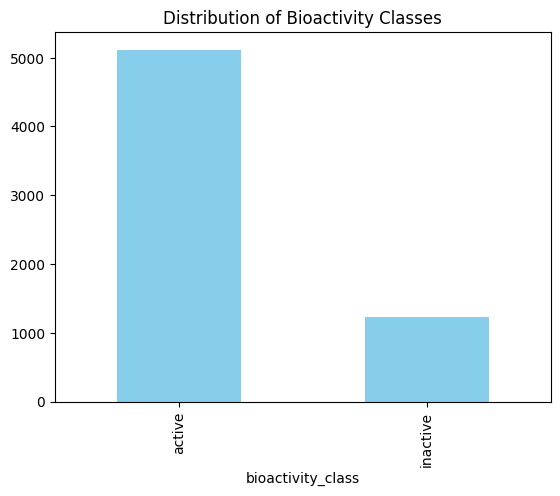

In [16]:
df['bioactivity_class'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of Bioactivity Classes')

In [17]:
df.describe(include='all')

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class
count,6341,6341.000000,6341.000000,6341.000000,6341.000000,6341.000000,6341
unique,5470,NaN,NaN,NaN,NaN,NaN,2
top,O=C(CCCCCCC(=O)Nc1ccccc1)NO,NaN,NaN,NaN,NaN,NaN,active
freq,247,NaN,NaN,NaN,NaN,NaN,5118
mean,NaN,423.154674,3.607172,2.886296,5.617726,6.739003,NaN
std,NaN,120.324203,1.446058,1.146729,2.446312,1.297159,NaN
min,NaN,75.067000,-14.260700,0.000000,0.000000,2.390000,NaN
25%,NaN,345.786000,2.579300,2.000000,4.000000,6.150000,NaN
50%,NaN,405.477000,3.520340,3.000000,5.000000,6.860000,NaN
75%,NaN,484.603000,4.485520,3.000000,7.000000,7.600000,NaN


<!-- #### Feature Transformation -->

In [4]:
df_cleaned=pd.read_excel("bioactivity_dataset_cleaned.xlsx", sheet_name="Sheet1")
df_cleaned.head(3)

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,6,8.6,active
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,6,9.0,active
2,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4,4,9.0,active


In [4]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['bioactivity_class'], drop_first=True)
df_cleaned.head(5)

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class_inactive
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,6,8.6,False
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,6,9.0,False
2,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4,4,9.0,False
3,O=C(CCCCCCC(=O)Nc1ccccc1)NO,264.325,2.4711,3,3,6.7,False
4,O=C(CCCCCC/C(=N\O)c1ccc(-c2ccccc2)cc1)NO,340.423,4.3779,3,4,8.4,False


Text(0.5, 1.0, 'Distribution of Bioactivity Classes')

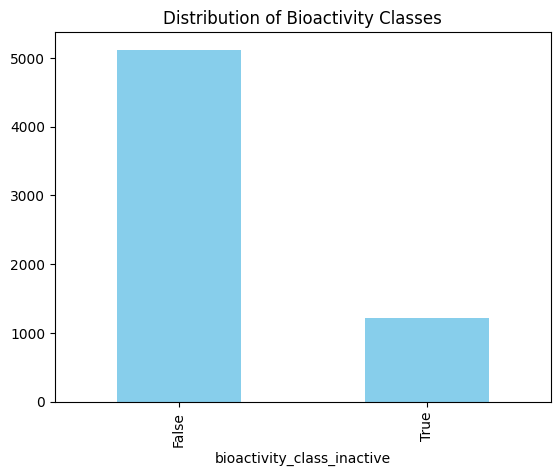

In [5]:
df_cleaned['bioactivity_class_inactive'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of Bioactivity Classes')

In [6]:
features_df = df_cleaned.drop(['bioactivity_class_inactive', 'pIC50'], axis=1)
target_df = df_cleaned['bioactivity_class_inactive']

In [7]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6341 entries, 0 to 6340
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   canonical_smiles            6341 non-null   object 
 1   MW                          6341 non-null   float64
 2   LogP                        6341 non-null   float64
 3   NumHDonors                  6341 non-null   int64  
 4   NumHAcceptors               6341 non-null   int64  
 5   pIC50                       6341 non-null   float64
 6   bioactivity_class_inactive  6341 non-null   bool   
dtypes: bool(1), float64(3), int64(2), object(1)
memory usage: 303.6+ KB


In [ ]:
# smiles= features_df['canonical_smiles']

In [8]:
numerical_cols= features_df.select_dtypes(include=[np.number]).columns.tolist()

In [9]:
numerical_cols

['MW', 'LogP', 'NumHDonors', 'NumHAcceptors']

Text(0.5, 1.0, 'Boxplots of Numerical Features')

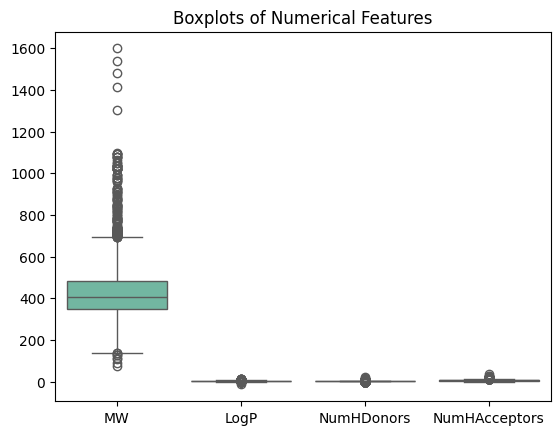

In [10]:
sns.boxplot(data=features_df[numerical_cols], orient='v', palette='Set2')
plt.title('Boxplots of Numerical Features')

In [12]:
# # Calculate Q1 (25th percentile) and Q3 (75th percentile) for each column
# Q1 = features_df[numerical_cols].quantile(0.25)
# Q3 = features_df[numerical_cols].quantile(0.75)

# # Calculate the IQR for each column
# IQR = Q3 - Q1

# # Define the lower and upper bounds for outliers
# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR

# # Identify rows where the data points are outside the bounds
# outliers = ((features_df[numerical_cols] < lower_bound) | (features_df[numerical_cols] > upper_bound)).any(axis=1)

# # Remove outliers from the dataset
# features_df = features_df[~outliers]

# # Check the result
# print(f"Original dataset size: {features_df.shape[0]}")
# print(f"Dataset size after removing outliers: {features_df.shape[0]}")

#features_df=features_df.copy()


Text(0.5, 1.0, 'Boxplots of Numerical Features')

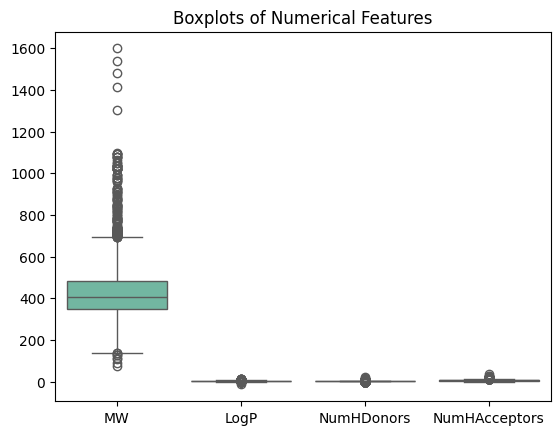

In [11]:

sns.boxplot(data=features_df[numerical_cols], orient='v', palette='Set2')
plt.title('Boxplots of Numerical Features')

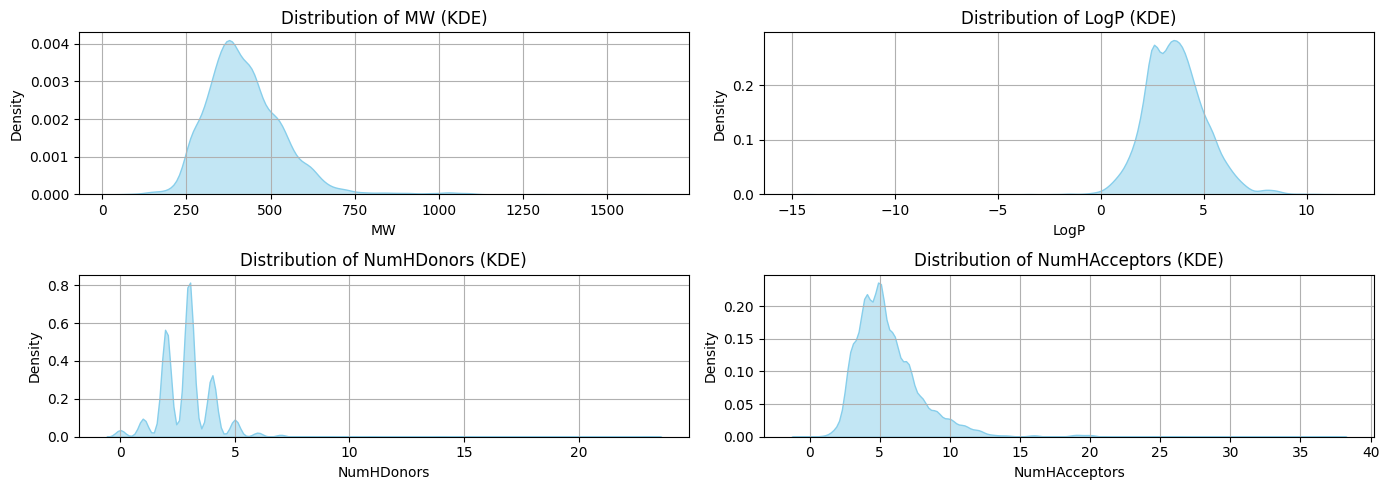

In [12]:

# If there are more than one plot, arrange two plots per row
fig, axes = plt.subplots(nrows=(len(numerical_cols) + 1) // 2, ncols=2, figsize=(14, 2.5 * ((len(numerical_cols) + 1) // 2)))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].set_title(f'Distribution of {col} (KDE)')
    sns.kdeplot(features_df[col], ax=axes[i], color='skyblue', fill=True, alpha=0.5)
    axes[i].set_ylabel('Density')
    axes[i].grid()
    axes[i].set_xlabel(col)
plt.tight_layout()
plt.show()

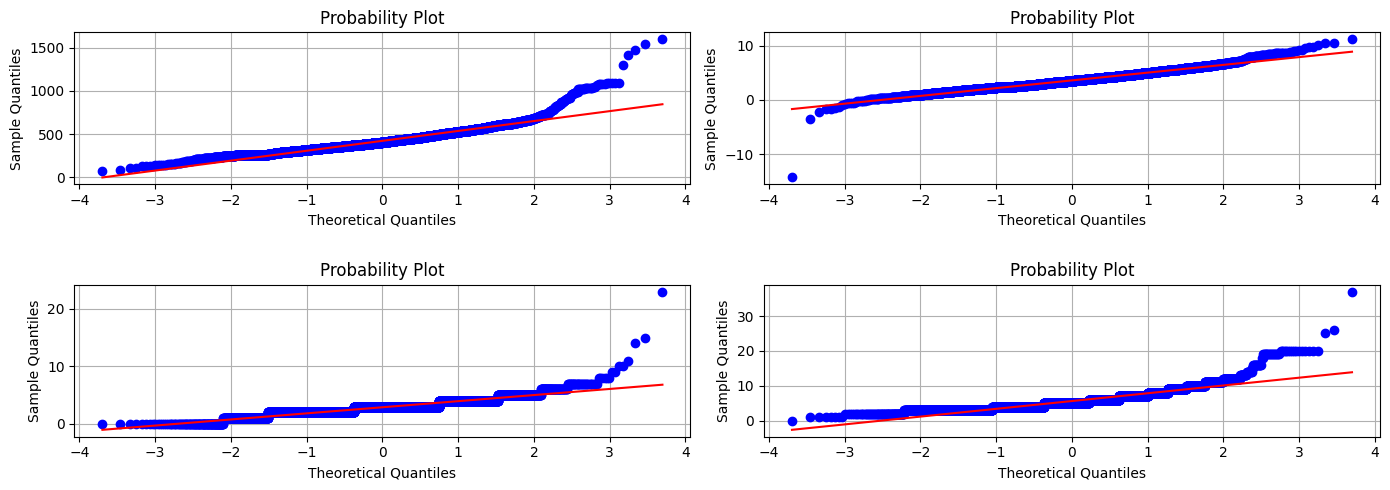

In [13]:
import scipy.stats as stats

fig, axes = plt.subplots(nrows=(len(numerical_cols) + 1) // 2, ncols=2, figsize=(14, 2.5 * ((len(numerical_cols) + 1) // 2)))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    axes[i].set_title(f'Q-Q Plot of {col}')
    stats.probplot(features_df[col], dist="norm", plot=axes[i])
    axes[i].set_xlabel('Theoretical Quantiles')
    # Add gap between rows by increasing vertical space between subplots
    plt.tight_layout(h_pad=2.5)
    axes[i].set_ylabel('Sample Quantiles')
    axes[i].grid()

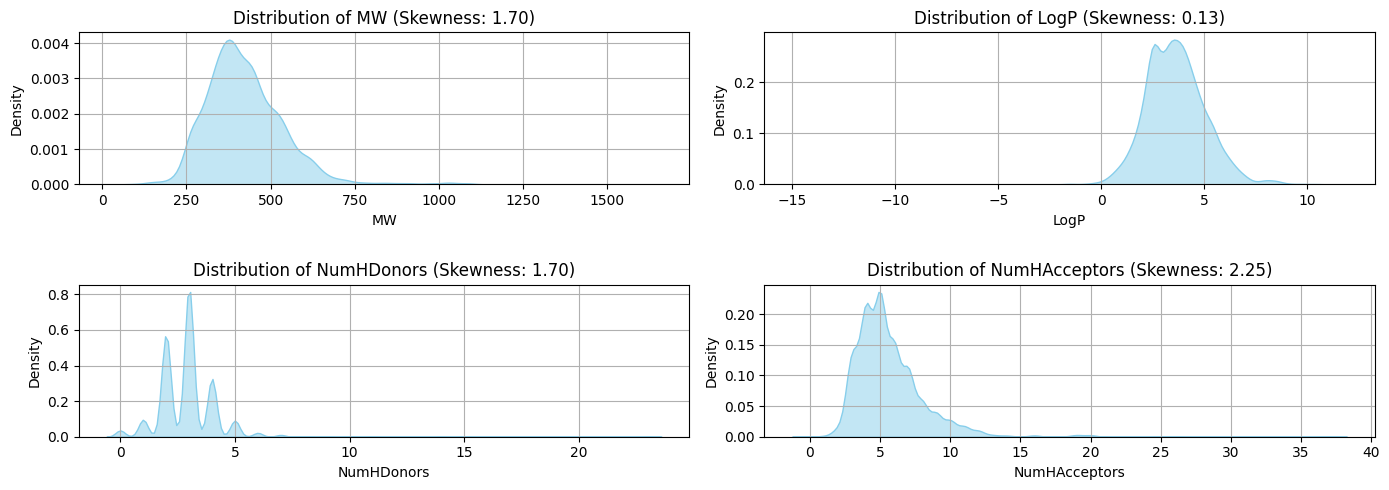

In [18]:
fig, axes = plt.subplots(nrows=(len(numerical_cols) + 1) // 2, ncols=2, figsize=(14, 2.5 * ((len(numerical_cols) + 1) // 2)))
axes = axes.flatten()
for i, column in enumerate(numerical_cols):
    skewness = stats.skew(features_df[column])  # Calculate skewness
    
    # Plot histogram for visual inspection
    sns.kdeplot(features_df[column], ax=axes[i], color='skyblue', fill=True, alpha=0.5)
    axes[i].set_title(f'Distribution of {column} (Skewness: {skewness:.2f})')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Density')
    axes[i].grid()
    plt.tight_layout(h_pad=2.5)
plt.show()

In [19]:
for column in numerical_cols:
    stat, p_value = stats.normaltest(features_df[column])
    print(f'Normality Test for {column}: Stat={stat:.3f}, p-value={p_value:.3f}')
    if p_value < 0.05:
        print(f'{column} is significantly not normal (p < 0.05)')
    else:
        print(f'{column} is approximately normal (p >= 0.05)')

Normality Test for MW: Stat=2536.683, p-value=0.000
MW is significantly not normal (p < 0.05)
Normality Test for LogP: Stat=663.415, p-value=0.000
LogP is significantly not normal (p < 0.05)
Normality Test for NumHDonors: Stat=3107.232, p-value=0.000
NumHDonors is significantly not normal (p < 0.05)
Normality Test for NumHAcceptors: Stat=3327.011, p-value=0.000
NumHAcceptors is significantly not normal (p < 0.05)


In [20]:
import scipy

features_df['MW']=np.log(features_df['MW']+1)
features_df['NumHDonors']=np.log(features_df['NumHDonors']+1)
features_df['NumHAcceptors']=np.log(features_df['NumHAcceptors']+1)

In [21]:
for column in numerical_cols:
    stat, p_value = stats.normaltest(features_df[column])
    print(f'Normality Test for {column}: Stat={stat:.3f}, p-value={p_value:.3f}')
    if p_value < 0.05:
        print(f'{column} is significantly not normal (p < 0.05)')
    else:
        print(f'{column} is approximately normal (p >= 0.05)')

Normality Test for MW: Stat=240.686, p-value=0.000
MW is significantly not normal (p < 0.05)
Normality Test for LogP: Stat=663.415, p-value=0.000
LogP is significantly not normal (p < 0.05)
Normality Test for NumHDonors: Stat=1549.697, p-value=0.000
NumHDonors is significantly not normal (p < 0.05)
Normality Test for NumHAcceptors: Stat=319.645, p-value=0.000
NumHAcceptors is significantly not normal (p < 0.05)


In [22]:
for col in numerical_cols:
    features_df[col] = (features_df[col] - features_df[col].mean()) / features_df[col].std()
features_df[numerical_cols].head(3)

,MW,LogP,NumHDonors,NumHAcceptors
0,0.483099,0.219236,0.943334,0.344859
1,0.648027,0.570605,0.943334,0.344859
2,0.067137,-0.028334,0.943334,-0.692281


In [23]:
for col in numerical_cols:
    skewness = stats.skew(features_df[col])  # Calculate skewness
    print(f'Skewness of {col}: {skewness:.2f}')
    
    if abs(skewness) > 0.5:
        print(f'{col} is significantly skewed (|Skewness| > 0.5)')
    else:
        print(f'{col} is approximately symmetric (|Skewness| <= 0.5)')

Skewness of MW: 0.03
MW is approximately symmetric (|Skewness| <= 0.5)
Skewness of LogP: 0.13
LogP is approximately symmetric (|Skewness| <= 0.5)
Skewness of NumHDonors: -1.15
NumHDonors is significantly skewed (|Skewness| > 0.5)
Skewness of NumHAcceptors: 0.47
NumHAcceptors is approximately symmetric (|Skewness| <= 0.5)


In [24]:
for column in numerical_cols:
    stat, p_value = stats.normaltest(features_df[column])
    print(f'Normality Test for {column}: Stat={stat:.3f}, p-value={p_value:.3f}')
    if p_value < 0.05:
        print(f'{column} is significantly not normal (p < 0.05)')
    else:
        print(f'{column} is approximately normal (p >= 0.05)')

Normality Test for MW: Stat=240.686, p-value=0.000
MW is significantly not normal (p < 0.05)
Normality Test for LogP: Stat=663.415, p-value=0.000
LogP is significantly not normal (p < 0.05)
Normality Test for NumHDonors: Stat=1549.697, p-value=0.000
NumHDonors is significantly not normal (p < 0.05)
Normality Test for NumHAcceptors: Stat=319.645, p-value=0.000
NumHAcceptors is significantly not normal (p < 0.05)


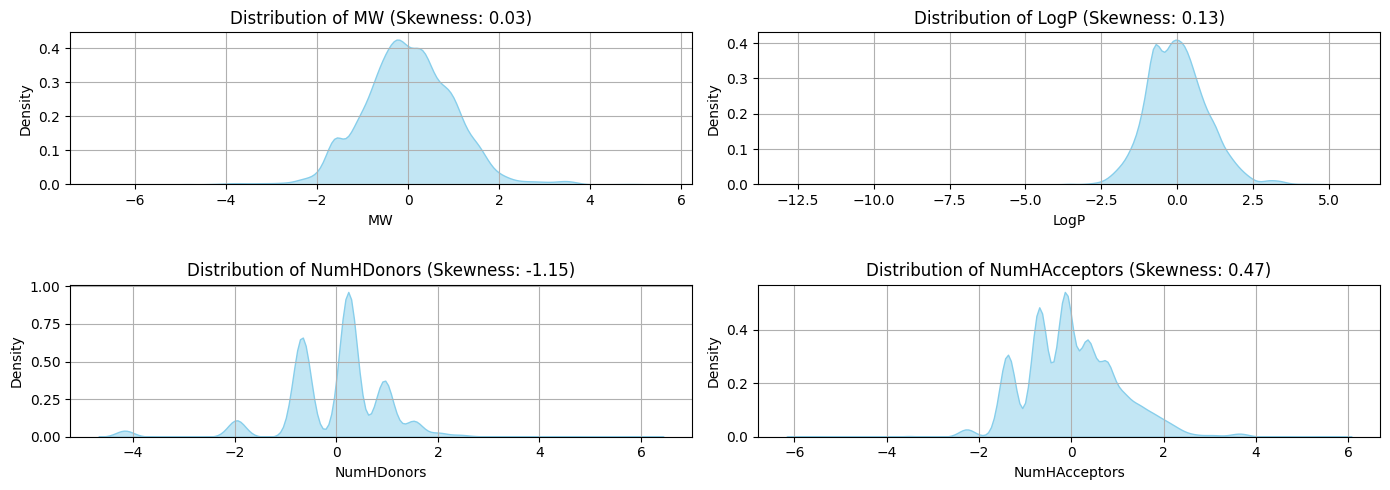

In [25]:
fig, axes = plt.subplots(nrows=(len(numerical_cols) + 1) // 2, ncols=2, figsize=(14, 2.5 * ((len(numerical_cols) + 1) // 2)))
axes = axes.flatten()
for i, column in enumerate(numerical_cols):
    skewness = stats.skew(features_df[column])  # Calculate skewness
    
    # Plot histogram for visual inspection
    sns.kdeplot(features_df[column], ax=axes[i], color='skyblue', fill=True, alpha=0.5)
    axes[i].set_title(f'Distribution of {column} (Skewness: {skewness:.2f})')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Density')
    axes[i].grid()
    plt.tight_layout(h_pad=2.5)
plt.show()

In [26]:
features_df[numerical_cols].head(3)

,MW,LogP,NumHDonors,NumHAcceptors
0,0.483099,0.219236,0.943334,0.344859
1,0.648027,0.570605,0.943334,0.344859
2,0.067137,-0.028334,0.943334,-0.692281


In [27]:
df_cleaned.head(3)

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class_inactive
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,6,8.6,False
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,6,9.0,False
2,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4,4,9.0,False


##### RDKit

In [14]:
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdFingerprintGenerator
from rdkit import Chem

features = []

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1000)
    
for idx, row in features_df.iterrows():
    # Convert SMILES to molecule object
    smile= row['canonical_smiles']
    mol = Chem.MolFromSmiles(smile)
    
    if mol:
        # Compute Morgan Fingerprints (ECFP)
        fingerprint = morgan_gen.GetFingerprint(mol)
        fingerprint_array = list(fingerprint)  # Convert to list
        
        # Compute bmolecular descriptors
        # molb_weight = Descriptors.MolWt(mol)  # Molecular Weight
        # logp = Descriptors.MolLogP(mol)  # LogP (Lipophilicity)
        # tpsa = Descriptors.TPSA(mol)  # Topological Polar Surface Area
        
        # Collect features (fingerprint + descriptors)
        features.append(fingerprint_array + [row['MW'], row['LogP'], row['NumHDonors'],
                                                row['NumHAcceptors']])

# Convert the features into a pandas DataFrame
X = pd.DataFrame(features)


##### DeepChem

In [27]:
%pip install deepchem

import deepchem as dc
from rdkit import Chem

# Use DeepChem's MolGraphConvFeaturizer to convert SMILES to molecular graph features
featurizer = dc.feat.MolGraphConvFeaturizer()

# This will create a list of graph features for each molecule
features_df['molecular_graph'] = features_df['canonical_smiles'].apply(lambda x: featurizer.featurize([x])[0])

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\BioActivity\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\BioActivity\.venv\Lib\site-packages\deepchem\feat\smiles_tokenizer.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


ModuleNotFoundError: No module named 'tensorflow'

In [40]:
features_df=features_df.drop(['canonical_smiles'], axis=1)

In [42]:
features_df.head(3)

,MW,LogP,NumHDonors,NumHAcceptors,molecular_graph
0,0.483099,0.219236,0.943334,0.344859,"GraphData(node_features=[34, 30], edge_index=[..."
1,0.648027,0.570605,0.943334,0.344859,"GraphData(node_features=[36, 30], edge_index=[..."
2,0.067137,-0.028334,0.943334,-0.692281,"GraphData(node_features=[31, 30], edge_index=[..."


In [44]:
features_df["graph_features"] = [graph.node_features for graph in features_df['molecular_graph']]
features_df.drop(['molecular_graph'], axis=1, inplace=True)
features_df.head(3)

,MW,LogP,NumHDonors,NumHAcceptors,graph_features
0,0.483099,0.219236,0.943334,0.344859,"[[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1,0.648027,0.570605,0.943334,0.344859,"[[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
2,0.067137,-0.028334,0.943334,-0.692281,"[[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


##### ChemBERTa

In [49]:
from transformers import BertModel, AutoTokenizer
import torch

# Load pretrained ChemBERTa model (PyTorch version)
model = BertModel.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")
tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")

# Encode the SMILES string into embeddings
def get_chemberta_embedding(smiles):
    inputs = tokenizer(smiles, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).detach().numpy()

features_df['chemberta_embedding'] = features_df['canonical_smiles'].apply(get_chemberta_embedding)


You are using a model of type roberta to instantiate a model of type bert. This is not supported for all configurations of models and can yield errors.
Some weights of BertModel were not initialized from the model checkpoint at seyonec/ChemBERTa-zinc-base-v1 and are newly initialized: ['embeddings.LayerNorm.bias', 'embeddings.LayerNorm.weight', 'embeddings.position_embeddings.weight', 'embeddings.token_type_embeddings.weight', 'embeddings.word_embeddings.weight', 'encoder.layer.0.attention.output.LayerNorm.bias', 'encoder.layer.0.attention.output.LayerNorm.weight', 'encoder.layer.0.attention.output.dense.bias', 'encoder.layer.0.attention.output.dense.weight', 'encoder.layer.0.attention.self.key.bias', 'encoder.layer.0.attention.self.key.weight', 'encoder.layer.0.attention.self.query.bias', 'encoder.layer.0.attention.self.query.weight', 'encoder.layer.0.attention.self.value.bias', 'encoder.layer.0.attention.self.value.weight', 'encoder.layer.0.intermediate.dense.bias', 'encoder.layer.0.

In [50]:
features_df.head(3)

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,chemberta_embedding
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,0.483099,0.219236,0.943334,0.344859,"[[-0.23707804, 0.49395293, 0.24604033, 0.39372..."
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,0.648027,0.570605,0.943334,0.344859,"[[-0.2607426, 0.5720752, 0.30183813, 0.4454808..."
2,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,0.067137,-0.028334,0.943334,-0.692281,"[[-0.22725658, 0.40469354, 0.2657733, 0.412880..."


In [52]:
features_df['chemberta_embedding'][0].shape

(1, 768)

In [53]:
X=features_df.drop(['canonical_smiles'], axis=1)

In [54]:
X = X.set_index(features_df.index)
y = target_df.loc[features_df.index]

In [57]:
print(X.shape, y.shape)

(6341, 5) (6341,)


In [58]:
X

,MW,LogP,NumHDonors,NumHAcceptors,chemberta_embedding
0,0.483099,0.219236,0.943334,0.344859,"[[-0.23707804, 0.49395293, 0.24604033, 0.39372..."
1,0.648027,0.570605,0.943334,0.344859,"[[-0.2607426, 0.5720752, 0.30183813, 0.4454808..."
2,0.067137,-0.028334,0.943334,-0.692281,"[[-0.22725658, 0.40469354, 0.2657733, 0.412880..."
3,-1.616230,-0.785634,0.234994,-1.380096,"[[0.020684434, 0.4703463, 0.16719496, 0.629871..."
4,-0.674613,0.532985,0.234994,-0.692281,"[[-0.27644372, 0.5241341, 0.23280697, 0.511133..."
...,...,...,...,...,...
6336,-0.556850,-0.909211,0.234994,-0.130294,"[[-0.3302253, 0.6001225, 0.21501105, 0.2417253..."
6337,-1.616230,-0.785634,0.234994,-1.380096,"[[-0.30155748, 0.66687113, 0.18498448, 0.31351..."
6338,-0.023540,0.483125,0.234994,0.756455,"[[-0.23910008, 0.5743231, 0.25488824, 0.486559..."
6339,-1.616230,-0.785634,0.234994,-1.380096,"[[-0.38627326, 0.6163624, 0.15096714, 0.402964..."


In [61]:
first_embedding = np.array(X['chemberta_embedding'].iloc[0])
print(f"Shape of a single embedding: {first_embedding.shape}")

Shape of a single embedding: (1, 768)


In [64]:
def squeeze_embedding(embedding_list):
    """
    Squeezes a pre-pooled embedding of shape (1, d) into shape (d,)
    """
    return np.array(embedding_list).squeeze() # .squeeze() removes dimensions of size 1

# Apply the function to the whole column
X['squeezed_embedding'] = X['chemberta_embedding'].apply(squeeze_embedding)

# 3. Create the final feature set
# Get the traditional features
traditional_features = X[['MW', 'LogP', 'NumHDonors', 'NumHAcceptors']].values

# Stack the squeezed embeddings into a matrix
embedding_matrix = np.vstack(X['squeezed_embedding'].values)

# Combine them by concatenating the columns
final_feature_matrix = np.hstack((traditional_features, embedding_matrix))

print(f"Traditional features shape: {traditional_features.shape}")
print(f"Embedding matrix shape: {embedding_matrix.shape}")
print(f"Final combined feature matrix shape: {final_feature_matrix.shape}")

Traditional features shape: (6341, 4)
Embedding matrix shape: (6341, 768)
Final combined feature matrix shape: (6341, 772)


In [89]:
# Extract the embeddings and convert them into a usable format (e.g., an array)
embeddings = np.array(X['chemberta_embedding'].tolist())
embeddings.shape

(6341, 1, 768)

<!-- #### Model Training -->

##### Data Fecthing

In [2]:
numerical_cols = ['MW', 'LogP', 'TPSA', 'NumHDonors', 'NumRotatableBonds', 'FractionCSP3', 'RingCount']  

In [3]:
cleaned_df=pd.read_excel("bioactivity_dataset_cleaned_new.xlsx")
cleaned_df.head(2)

,canonical_smiles,MW,LogP,NumHDonors,TPSA,NumRotatableBonds,FractionCSP3,RingCount,bioactivity
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,129.65,11,0.280000,3,1
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,133.31,10,0.222222,4,1


In [4]:
features_df = cleaned_df.drop(['bioactivity'], axis=1)
target_df = cleaned_df['bioactivity']

In [178]:
# fig, axes = plt.subplots(nrows=(len(numerical_cols) + 1) // 2, ncols=2, figsize=(14, 2.5 * ((len(numerical_cols) + 1) // 2)))
# axes = axes.flatten()

# for i, col in enumerate(numerical_cols):
#     axes[i].set_title(f'Distribution of {col} (KDE)')
#     sns.kdeplot(features_df[col], ax=axes[i], color='skyblue', fill=True, alpha=0.5)
#     axes[i].set_ylabel('Density')
#     axes[i].grid()
#     axes[i].set_xlabel(col)
# plt.tight_layout()
# plt.show()

In [5]:
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdFingerprintGenerator
from rdkit import Chem

features = []

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1000)
    
for idx, row in features_df.iterrows():
    # Convert SMILES to molecule object
    smile= row['canonical_smiles']
    mol = Chem.MolFromSmiles(smile)
    
    if mol:
        # Compute Morgan Fingerprints (ECFP)
        fingerprint = morgan_gen.GetFingerprint(mol)
        fingerprint_array = list(fingerprint)  # Convert to list
        
        # Compute bmolecular descriptors
        # molb_weight = Descriptors.MolWt(mol)  # Molecular Weight
        # logp = Descriptors.MolLogP(mol)  # LogP (Lipophilicity)
        #tpsa = Descriptors.TPSA(mol)  # Topological Polar Surface Area
        
        # Collect features (fingerprint + descriptors)
        features.append(fingerprint_array + [row['MW'], row['LogP'], row['TPSA'], row['NumHDonors'],
                                                row['NumRotatableBonds'], row['FractionCSP3'], row['RingCount']])

# Convert the features into a pandas DataFrame
X = pd.DataFrame(features)
X.shape

(6341, 1007)

In [6]:
len(features_df), len(target_df)

(6341, 6341)

In [7]:
X = X.set_index(features_df.index)
y = target_df.loc[features_df.index]

In [8]:
X.head(3)

,0,1,2,3,4,5,6,7,8,9,...,997,998,999,1000,1001,1002,1003,1004,1005,1006
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,464.522,3.9242,129.65,4,11,0.280000,3
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,485.544,4.4323,133.31,4,10,0.222222,4
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,415.449,3.5662,107.53,4,7,0.041667,3


<!-- ##### Train Test Split -->

In [9]:

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from sklearn.preprocessing import StandardScaler

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
#X_train, y_train = SMOTE(random_state=42).fit_resample(X_train, y_train)

# Feature scaling (needed for some base estimators)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)  
print(X_test.shape, y_test.shape)



(4438, 1007) (4438,)
(951, 1007) (951,)
(952, 1007) (952,)


In [ ]:
# cols_to_plot = X_train.columns[1000:1008]
# fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 12))
# axes = axes.flatten()

# for i, col in enumerate(cols_to_plot):
#     sns.kdeplot(stat_x_train[col], ax=axes[i], color='skyblue', fill=True, alpha=0.5)
#     axes[i].set_title(f'Distribution of {col}')
#     axes[i].set_xlabel(col)
#     axes[i].set_ylabel('Density')
#     axes[i].grid()

# plt.tight_layout()
# plt.show()

In [10]:
print(y_train.value_counts())
print(y_val.value_counts())
print(y_test.value_counts())

bioactivity
1    3582
0     856
Name: count, dtype: int64
bioactivity
1    764
0    187
Name: count, dtype: int64
bioactivity
1    772
0    180
Name: count, dtype: int64


In [205]:
cols=numerical_cols
col_positions = X.columns[1000:1007]

col_map={old_col: new_col for old_col, new_col in zip(col_positions, cols)}

stat_x_train=X_train.rename(columns=col_map)
stat_x_val=X_val.rename(columns=col_map)
stat_x_test=X_test.rename(columns=col_map)

stat_x = X.rename(columns=col_map)

AttributeError: 'numpy.ndarray' object has no attribute 'rename'

In [14]:
y_train.value_counts()

bioactivity
1    3582
0     856
Name: count, dtype: int64

In [15]:
y_train==1

860     False
1538    False
1663     True
4586     True
1271     True
        ...  
574      True
4593     True
2880     True
5294    False
6254     True
Name: bioactivity, Length: 4438, dtype: bool

##### Statistical Testing

In [203]:
from scipy.stats import ttest_ind

print("Performing t-test for descriptor significance...")
p_values = {}
for col in numerical_cols:
    group0 = stat_x_train[y_train == 0][col]
    group1 = stat_x_train[y_train == 1][col]
    t_stat, p_val = ttest_ind(group0, group1, nan_policy='omit')
    p_values[col] = p_val
    mean0 = group0.mean()
    mean1 = group1.mean()
    print(f"{col}: Inactive mean = {mean0:.2f}, Active mean = {mean1:.2f}, t-stat = {t_stat}, p-value = {p_val:.50f}")
significant_features = [col for col, p_val in p_values.items() if p_val < 0.05]
print("Significant descriptors (p < 0.05):", significant_features)

Performing t-test for descriptor significance...


NameError: name 'stat_x_train' is not defined

In [44]:
y_train[y_train==0].value_counts().sum()/y_train.value_counts().sum()

0.18111625854842267

Generating t-SNE visualization...


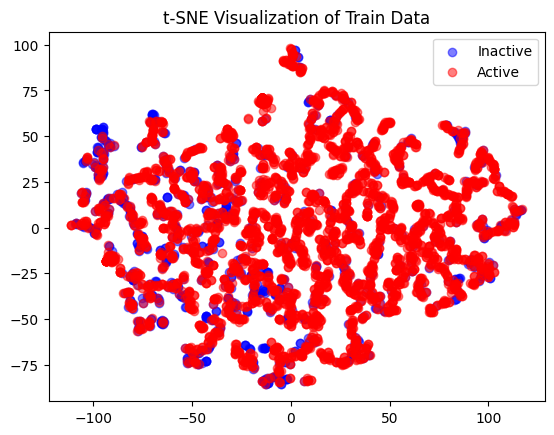

In [46]:
from sklearn.manifold import TSNE
print("Generating t-SNE visualization...")
# Use all features (embeddings + descriptors) for visualization
tsne = TSNE(n_components=2, perplexity=10, random_state=42)
X_tsne = tsne.fit_transform(X_train)
plt.scatter(X_tsne[y_train == 0, 0], X_tsne[y_train == 0, 1], label="Inactive", alpha=0.5, c='blue')
plt.scatter(X_tsne[y_train == 1, 0], X_tsne[y_train == 1, 1], label="Active", alpha=0.5, c='red')
plt.legend()
plt.title("t-SNE Visualization of Train Data")
plt.show()

e:\ML\BioActivity\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
e:\ML\BioActivity\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
e:\ML\BioActivity\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


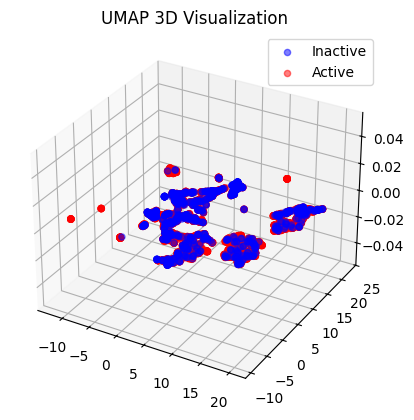

In [47]:
from umap.umap_ import UMAP
umap_model = UMAP(n_components=2, n_neighbors=7, min_dist=0.1, random_state=42)
X_umap = umap_model.fit_transform(X_train)
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_umap[y_train == 0, 0], X_umap[y_train == 0, 1],  c='blue', label="Inactive", alpha=0.5)
ax.scatter(X_umap[y_train == 1, 0], X_umap[y_train == 1, 1], c='red', label="Active", alpha=0.5)
ax.legend()
plt.title("UMAP 3D Visualization")
plt.show()

##### Utilities 

In [11]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    average_precision_score,
    cohen_kappa_score,
    brier_score_loss
)

def plot_confusion_matrix(y_test, y_pred):  
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()


def plot_roc_curve(y_test, y_prob):
    from sklearn.metrics import RocCurveDisplay
    RocCurveDisplay.from_predictions(y_test, y_prob)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.show()

def plot_auprc_curve(y_test, y_prob):
    from sklearn.metrics import PrecisionRecallDisplay
    PrecisionRecallDisplay.from_predictions(y_test, y_prob)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('AUPRC Curve')
    plt.show()


def calc_metrics(final_model):
    y_prob = final_model.predict_proba(X_test)[:, 1]  # Probabilities for positive class
    y_pred = final_model.predict(X_test)  # Binary predictions (threshold at 0.5)

    accuracy = accuracy_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    mcc = matthews_corrcoef(y_test, y_pred)
    auprc = average_precision_score(y_test, y_prob)
    kappa = cohen_kappa_score(y_test, y_pred, weights='quadratic')

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    npv = tn / (tn + fn) 
    specificity = tn / (tn + fp)
    sensitivity = recall  # same as recall
    informedness = sensitivity + specificity - 1

    dor = (tp * tn) / (fn * fp) if fp != 0 and fn != 0 else float('inf')

    brier = brier_score_loss(y_test, y_prob)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Balanced Acc.: {balanced_acc:.4f}")
    print(f"Cohen's Kappa: {kappa:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"AUPRC: {auprc:.4f}")
    print(f"MCC: {mcc:.4f}")
    print(f"NPV: {npv:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"Sensitivity: {sensitivity:.4f}")
    print("Informedness: {:.4f}".format(informedness))
    print(f"DOR: {dor:.4f}")
    print(f"Brier Score: {brier:.4f}")

    print("********************")
    print("Confusion Matrix:")
    plot_confusion_matrix(y_test, y_pred)

    print("ROC Curve:")
    plot_roc_curve(y_test, y_prob)

    print("AUPRC Curve:")
    plot_auprc_curve(y_test, y_prob)



In [12]:
from sklearn.metrics import log_loss
import numpy as np
import torch
import torch.nn as nn

# Focal Loss for Imbalanced Data (Test Set)

# Focal Loss implementation (binary classification)
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        BCE_loss = nn.BCEWithLogitsLoss(reduction='none')(inputs, targets)
        pt = torch.exp(-BCE_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * BCE_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        else:
            return focal_loss.sum()
        
def calc_loss(final_model):
    # Calculate log loss
    log_loss_value = log_loss(y_test, final_model.predict_proba(X_test))
    print("Log Loss(Test):", log_loss_value)

    log_loss_value = log_loss(y_train, final_model.predict_proba(X_train))
    print("Log Loss(Train):", log_loss_value)


    # Get predicted probabilities for the positive class
    y_proba = final_model.predict_proba(X_test)[:, 1]
    # Convert to logits (inverse of sigmoid)
    eps = 1e-8  # to avoid log(0)
    logits = np.log(y_proba / (1 - y_proba + eps) + eps)

    # Convert to torch tensors
    logits_tensor = torch.tensor(logits, dtype=torch.float32)
    targets_tensor = torch.tensor(y_test.values, dtype=torch.float32)

    # Calculate focal loss
    focal_loss_fn = FocalLoss(alpha=0.25, gamma=2.0)
    focal_loss_value = focal_loss_fn(logits_tensor, targets_tensor)
    print(f'Focal Loss (Test Set): {focal_loss_value.item():.4f}')

In [13]:
from pathlib import Path
import joblib
import json

Path("saved_model/ml_models").mkdir(parents=True, exist_ok=True)

def save_model(final_model, best_params, model_name):
    # Save the trained model (with compression)
    joblib.dump(final_model, f"saved_model/ml_models/{model_name}.pkl", compress=3)

    # Save simple metadata (e.g., columns and best params) for reproducibility
    metadata = {
        "model_type": type(final_model).__name__,
        "best_params": best_params if 'best_params' in globals() else None
    }
    with open(f"saved_model/ml_models/{model_name}_metadata.json", "w") as f:
        json.dump(metadata, f, indent=2)

    print("Model and metadata saved to saved_model/ml_models/")

In [14]:
def shap_plot(final_model):
    import shap

    # Create a SHAP explainer
    #explainer = shap.TreeExplainer(final_model, X_train)
    explainer = shap.Explainer(final_model, X_train)

    # Calculate SHAP values for the test set
    shap_values = explainer.shap_values(X_test)

    # Plot summary plot
    #shap.summary_plot(shap_values, X_test, plot_type="bar")

    #emb_idx = slice(0, 1000)  # e.g., 0:1000
    #desc_idx = slice(1000, 1004)

    #print("Desc Index: " ,desc_idx)

    #explainer = shap.TreeExplainer(final_model)
    #shap_values = explainer.shap_values(X_test)  # Shape: [n_samples, n_features]

    # Overall importance
    #mean_abs_shap = np.abs(shap_values).mean(0)
    #print("Embedding total importance:", mean_abs_shap[emb_idx].sum())
    #print("Descriptors importance:", mean_abs_shap[desc_idx])

    plt.figure(figsize=(8,8))
    shap.summary_plot(shap_values, X_test)  # Clean plot!



In [15]:
from lime.lime_tabular import LimeTabularExplainer

def lime_plot(final_model):
    def predict_proba_wrapper(X):
        return final_model.predict_proba(X)

    explainer = LimeTabularExplainer(
        X_train, 
        class_names=["0", "1"], 
        mode="classification"
    )


    exp = explainer.explain_instance(
        X_test[0], 
        predict_proba_wrapper,
        num_features=10
    )

    # OPTION 2: Show as matplotlib figure
    fig = exp.as_pyplot_figure()
    plt.tight_layout()
    plt.show()

    # OPTION 3: Print as text
    print("\nFeature contributions:")
    print(exp.as_list())

    # OPTION 4: Get as dictionary
    print("\nExplanation as dict:")
    print(exp.as_map())


##### XGBoost

In [35]:
import optuna
import warnings
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

warnings.filterwarnings("ignore")


neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / (pos_count + 1e-8)
print(f"Class imbalance ratio: {scale_pos_weight:.2f}:1\n")


def objective(trial):
    param = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 50, 500, step=50),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-2, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 10.0, log=True),
        "scale_pos_weight": scale_pos_weight,
        "booster": trial.suggest_categorical("booster", ["gbtree", "gblinear", "dart"]),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "n_jobs": -1
    }
    # model = xgb.XGBClassifier(**param)
    # model.fit(X_train, y_train)
    # pred_prob = model.predict_proba(X_val)[:, 1]
    # auc = roc_auc_score(y_val, pred_prob)
    # return 1.0 - auc  # Optuna minimizes, so invert accuracy

    if param["booster"] == "gblinear":
        param.pop("max_depth", None)
        param.pop("min_child_weight", None)
        param.pop("subsample", None)
        param.pop("colsample_bytree", None)
    elif param["booster"] == "dart":
        param["rate_drop"] = trial.suggest_float("rate_drop", 1e-3, 0.2, log=True)
        param["skip_drop"] = trial.suggest_float("skip_drop", 1e-3, 0.2, log=True)
    
    # Convert to DMatrix for XGBoost
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    
    # Train model with early stopping
    model = xgb.train(
        param,
        dtrain,
        evals=[(dval, "validation")],
        early_stopping_rounds=10,
        num_boost_round=param["n_estimators"],
        verbose_eval=False
    )
    
    # Predict probabilities for AUC
    preds_proba = model.predict(dval)
    auc = roc_auc_score(y_val, preds_proba)
    
    return auc  # Optuna minimizes, so invert AUC

from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
study = optuna.create_study(direction='maximize',
        sampler=TPESampler(seed=42),
        pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=5))
study.optimize(objective, n_trials=31, show_progress_bar=True, )

print("Best trial:")
print(study.best_trial)
print("Best params:", study.best_params)

# Train final model with best params
best_params = study.best_params
best_params.update({"objective": "binary:logistic", "eval_metric": "auc", "use_label_encoder": False})

final_model_xgb = xgb.XGBClassifier(**best_params, n_jobs=-1)

X_train_full=np.vstack([X_train, X_val])
y_train_full=np.concatenate([y_train, y_val])
final_model_xgb.fit(X_train_full, y_train_full)
y_pred = final_model_xgb.predict(X_test)
print("Final Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

[I 2025-11-21 06:58:03,990] A new study created in memory with name: no-name-269a60cf-a5ae-4fab-9ebc-098bc50d4bf8


Class imbalance ratio: 0.24:1



Best trial: 0. Best value: 0.821563:   3%|▎         | 1/31 [00:00<00:06,  4.48it/s]

[I 2025-11-21 06:58:04,209] Trial 0 finished with value: 0.8215625612453453 and parameters: {'max_depth': 5, 'learning_rate': 0.22648248189516848, 'n_estimators': 400, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'gamma': 0.7799726016810132, 'reg_alpha': 0.014936568554617643, 'reg_lambda': 3.9676050770529883, 'booster': 'gblinear', 'min_child_weight': 10}. Best is trial 0 with value: 0.8215625612453453.


Best trial: 1. Best value: 0.896929:   6%|▋         | 2/31 [00:00<00:06,  4.78it/s]

...

[I 2025-11-21 06:58:56,015] Trial 27 finished with value: 0.9102878181258225 and parameters: {'max_depth': 7, 'learning_rate': 0.02324690231747366, 'n_estimators': 350, 'subsample': 0.7035126772723403, 'colsample_bytree': 0.6181176190750675, 'gamma': 0.4508184414100927, 'reg_alpha': 0.42389379994359794, 'reg_lambda': 0.5794659678406504, 'booster': 'gbtree', 'min_child_weight': 2}. Best is trial 25 with value: 0.9558123582607723.


Best trial: 28. Best value: 0.95661:  94%|█████████▎| 29/31 [00:53<00:01,  1.49it/s] 

[I 2025-11-21 06:58:56,952] Trial 28 finished with value: 0.9566102976173811 and parameters: {'max_depth': 6, 'learning_rate': 0.024604556240998776, 'n_estimators': 250, 'subsample': 0.8560181824647799, 'colsample_bytree': 0.536577440181966, 'gamma': 0.10205197910093805, 'reg_alpha': 0.05981493798813031, 'reg_lambda': 0.25150244014189765, 'booster': 'gbtree', 'min_child_weight': 1}. Best is trial 28 with value: 0.9566102976173811.
[I 2025-11-21 06:58:57,042] Trial 29 finished with value: 0.6981094436822801 and parameters: {'max_depth': 4, 'learning_rate': 0.016775716718079592, 'n_estimators': 200, 'subsample': 0.7996701187126671, 'colsample_bytree': 0.5496021886677683, 'gamma': 0.07623153444661174, 'reg_alpha': 0.04665057063865695, 'reg_lambda': 1.4430780812902708, 'booster': 'gblinear', 'min_child_weight': 1}. Best is trial 28 with value: 0.9566102976173811.


Best trial: 28. Best value: 0.95661: 100%|██████████| 31/31 [00:53<00:00,  1.72s/it]



[I 2025-11-21 06:58:57,236] Trial 30 finished with value: 0.9030223702998572 and parameters: {'max_depth': 6, 'learning_rate': 0.007211549712944126, 'n_estimators': 150, 'subsample': 0.8650322728930494, 'colsample_bytree': 0.5769084048711692, 'gamma': 0.6126893584639181, 'reg_alpha': 0.020928636151147366, 'reg_lambda': 0.3222265159836076, 'booster': 'gbtree', 'min_child_weight': 1}. Best is trial 28 with value: 0.9566102976173811.
Best trial:
FrozenTrial(number=28, state=1, values=[0.9566102976173811], datetime_start=datetime.datetime(2025, 11, 21, 6, 58, 56, 17356), datetime_complete=datetime.datetime(2025, 11, 21, 6, 58, 56, 952776), params={'max_depth': 6, 'learning_rate': 0.024604556240998776, 'n_estimators': 250, 'subsample': 0.8560181824647799, 'colsample_bytree': 0.536577440181966, 'gamma': 0.10205197910093805, 'reg_alpha': 0.05981493798813031, 'reg_lambda': 0.25150244014189765, 'booster': 'gbtree', 'min_child_weight': 1}, user_attrs={}, system_attrs={}, intermediate_values={}, 

Accuracy: 0.9160
Balanced Acc.: 0.8161
Cohen's Kappa: 0.6976
Precision: 0.9240
Recall: 0.9767
F1 Score: 0.9496
ROC-AUC: 0.9561
AUPRC: 0.9873
MCC: 0.7075
NPV: 0.8676
Specificity: 0.6556
Sensitivity: 0.9767
Informedness: 0.6322
DOR: 79.7240
Brier Score: 0.0583
********************
Confusion Matrix:


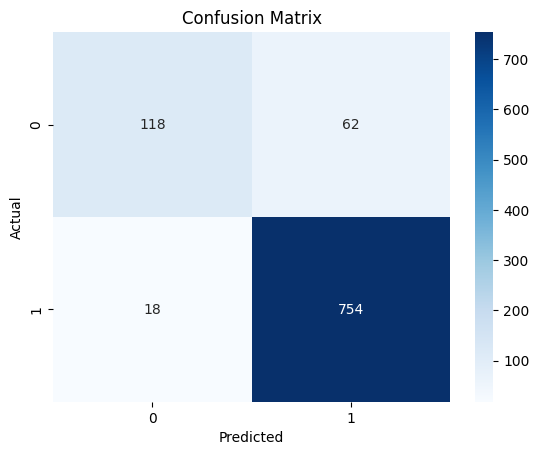

ROC Curve:


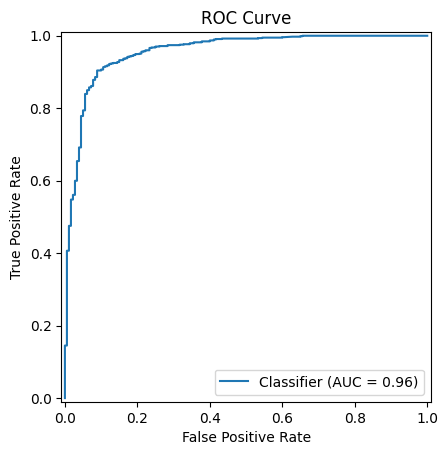

AUPRC Curve:


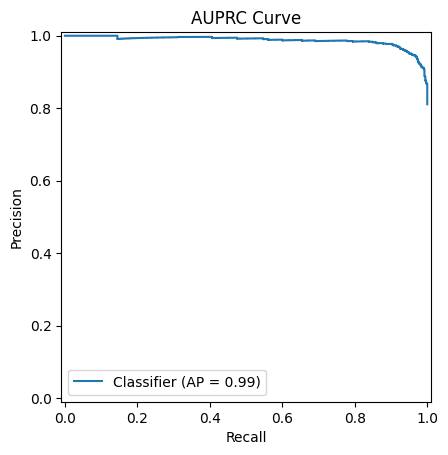

In [36]:
calc_metrics(final_model_xgb)

In [37]:
calc_loss(final_model_xgb)

Log Loss(Test): 0.2057851564617375
Log Loss(Train): 0.14283695348412928
Focal Loss (Test Set): 0.0190


In [40]:
save_model(final_model_xgb, best_params, "xgboost_bioactivity_model")

Model and metadata saved to saved_model/ml_models/


<Figure size 500x300 with 0 Axes>

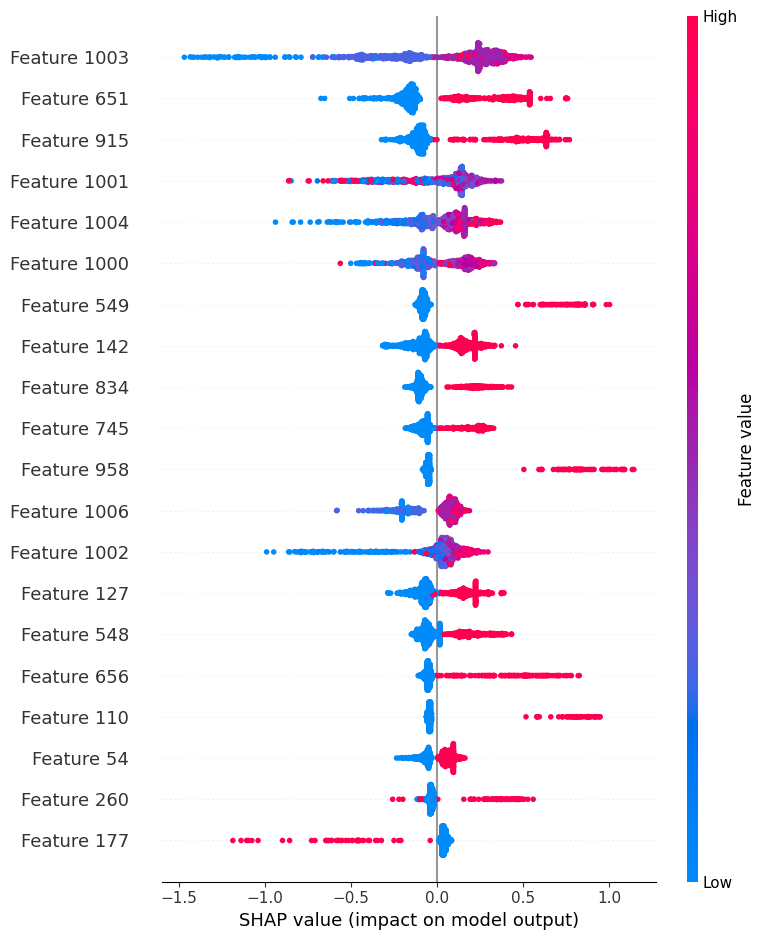

In [22]:
plt.figure(figsize=(5, 3)) 
shap_plot(final_model_xgb)

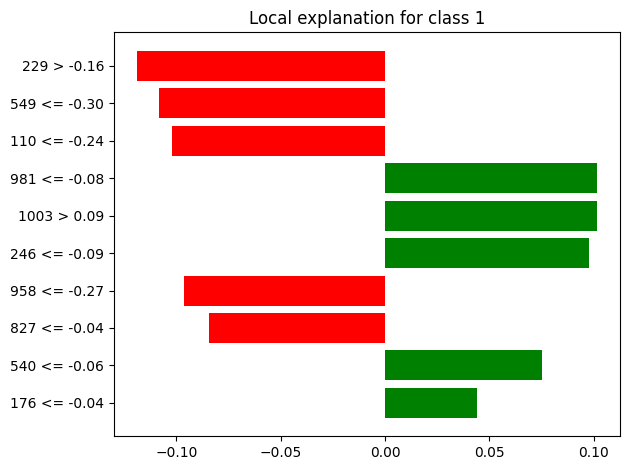


Feature contributions:
[('229 > -0.16', -0.1189106064526506), ('549 <= -0.30', -0.10858466817129142), ('110 <= -0.24', -0.10219089060524901), ('981 <= -0.08', 0.10156159742712495), ('1003 > 0.09', 0.10153925628508019), ('246 <= -0.09', 0.09789122511683497), ('958 <= -0.27', -0.09617679683841893), ('827 <= -0.04', -0.08457919881331719), ('540 <= -0.06', 0.07512800310221361), ('176 <= -0.04', 0.04402248617293167)]

Explanation as dict:
{1: [(229, -0.1189106064526506), (549, -0.10858466817129142), (110, -0.10219089060524901), (981, 0.10156159742712495), (1003, 0.10153925628508019), (246, 0.09789122511683497), (958, -0.09617679683841893), (827, -0.08457919881331719), (540, 0.07512800310221361), (176, 0.04402248617293167)]}


In [48]:
lime_plot(final_model_xgb)

##### RandomForest

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def objective(trial):

    
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None, 0.5, 1]),
        "max_samples": trial.suggest_float("max_samples", 0.5, 1.0),
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
        "class_weight": trial.suggest_categorical("class_weight", ["balanced", "balanced_subsample", None]),
        "random_state": 42
    }
   
    model = RandomForestClassifier(**param, n_jobs=-1)
    model.fit(X_train, y_train)

    # Evaluate on the validation set and compute ROC AUC using the positive-class probabilities
    preds_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, preds_proba)
    return auc  # Optuna minimizes, so invert AUC

study = optuna.create_study(direction='maximize',
        sampler=TPESampler(seed=42),
        pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=5))
study.optimize(objective, n_trials=31)

print("Best trial:")
print(study.best_trial)
print("Best params:", study.best_params)

# Train final model with best params
best_params = study.best_params
final_model_rf = RandomForestClassifier(**best_params, n_jobs=-1)


X_train_full=np.vstack([X_train, X_val])
y_train_full=np.concatenate([y_train, y_val])

final_model_rf.fit(X_train_full, y_train_full)
y_pred = final_model_rf.predict(X_test)
print("Final Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

[I 2025-11-21 07:00:02,360] A new study created in memory with name: no-name-58061e12-4852-4af5-acb6-3626d1a23b96
[I 2025-11-21 07:00:03,161] Trial 0 finished with value: 0.9559873449617828 and parameters: {'n_estimators': 218, 'max_depth': 20, 'min_samples_split': 8, 'min_samples_leaf': 6, 'max_features': 0.5, 'max_samples': 0.8540362888980227, 'criterion': 'entropy', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9559873449617828.
[I 2025-11-21 07:00:03,161] Trial 0 finished with value: 0.9559873449617828 and parameters: {'n_estimators': 218, 'max_depth': 20, 'min_samples_split': 8, 'min_samples_leaf': 6, 'max_features': 0.5, 'max_samples': 0.8540362888980227, 'criterion': 'entropy', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9559873449617828.
[I 2025-11-21 07:00:03,642] Trial 1 finished with value: 0.9060391410252822 and parameters: {'n_estimators': 132, 'max_depth': 8, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_samples': 

Best trial:
FrozenTrial(number=26, state=1, values=[0.9596410672788868], datetime_start=datetime.datetime(2025, 11, 21, 7, 0, 21, 184036), datetime_complete=datetime.datetime(2025, 11, 21, 7, 0, 21, 776313), params={'n_estimators': 88, 'max_depth': 18, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': None, 'max_samples': 0.9291742422581573, 'criterion': 'entropy', 'class_weight': 'balanced'}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=500, log=False, low=50, step=1), 'max_depth': IntDistribution(high=20, log=False, low=3, step=1), 'min_samples_split': IntDistribution(high=10, log=False, low=2, step=1), 'min_samples_leaf': IntDistribution(high=10, log=False, low=1, step=1), 'max_features': CategoricalDistribution(choices=('sqrt', 'log2', None, 0.5, 1)), 'max_samples': FloatDistribution(high=1.0, log=False, low=0.5, step=None), 'criterion': CategoricalDistribution(choices=('gini', 'entropy')), 'class_weight': 

Accuracy: 0.9233
Balanced Acc.: 0.8760
Cohen's Kappa: 0.7505
Precision: 0.9533
Recall: 0.9521
F1 Score: 0.9527
ROC-AUC: 0.9599
AUPRC: 0.9888
MCC: 0.7505
NPV: 0.7956
Specificity: 0.8000
Sensitivity: 0.9521
Informedness: 0.7521
DOR: 79.4595
Brier Score: 0.0544
********************
Confusion Matrix:


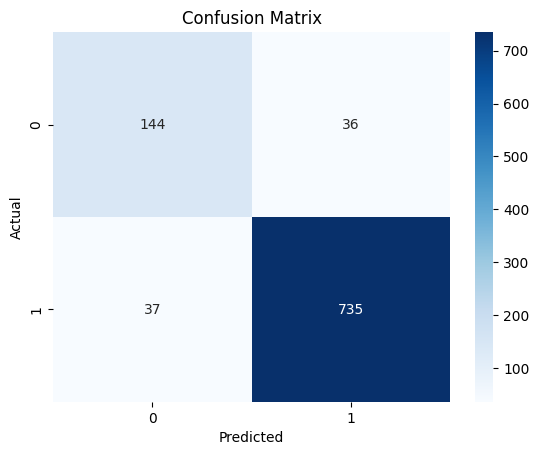

ROC Curve:


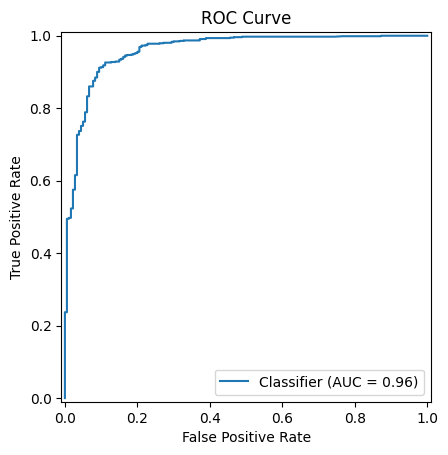

AUPRC Curve:


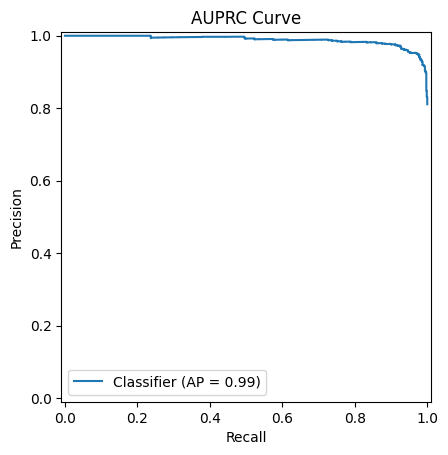

In [42]:
calc_metrics(final_model_rf)

In [43]:
calc_loss(final_model_rf)

Log Loss(Test): 0.19408406859882388
Log Loss(Train): 0.08556365378876186
Focal Loss (Test Set): 0.0170


In [44]:
save_model(final_model_rf, best_params, "random_forest_bioactivity_model")

Model and metadata saved to saved_model/ml_models/


 97%|=================== | 1104/1134 [00:29<00:00]       

<Figure size 800x800 with 0 Axes>

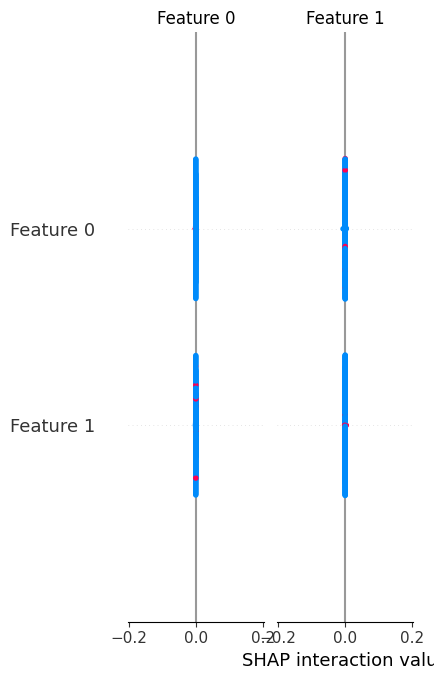

In [ ]:
shap_plot(final_model_rf)

In [33]:
# # Fix: Convert the first row to numpy array for LIME
# lime_plot(final_model_rf)

# # If you get a KeyError, try this:
# # lime_plot expects a numpy array for the instance, not a pandas Series.
# # Uncomment the following if you still get an error:

# # def lime_plot_fixed(final_model):
# #     def predict_proba_wrapper(X):
# #         return final_model.predict_proba(X)
# #     explainer = LimeTabularExplainer(
# #         X_train.values, 
# #         class_names=["0", "1"], 
# #         mode="classification"
# #     )
# #     exp = explainer.explain_instance(
# #         X_test.iloc[0].values,  # Convert to numpy array
# #         predict_proba_wrapper,
# #         num_features=10
# #     )
# #     fig = exp.as_pyplot_figure()
# #     plt.tight_layout()
# #     plt.show()
# #     print("\nFeature contributions:")
# #     print(exp.as_list())
# #     print("\nExplanation as dict:")
# #     print(exp.as_map())

# # lime_plot_fixed(final_model_rf)

##### LightGBM

In [50]:
import optuna
import lightgbm as lgbm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def objective(trial):
    param = {
        "objective": "binary",
        "metric": "auc",
        "verbosity": -1,
        "boosting_type": trial.suggest_categorical("boosting_type", ["gbdt", "goss", "rf"]),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "num_leaves": trial.suggest_int("num_leaves", 7, 128),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 50, 500, step=50),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 10.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-2, 10.0, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "scale_pos_weight": scale_pos_weight,
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 100, step=10),
    }
    if param["boosting_type"] == "goss":
        param["top_rate"] = trial.suggest_float("top_rate", 0.1, 0.4)
        param["other_rate"] = trial.suggest_float("other_rate", 0.05, 0.3)
    elif param["boosting_type"] == "rf":
        param["bagging_freq"] = trial.suggest_int("bagging_freq", 1, 10)
        param["bagging_fraction"] = trial.suggest_float("bagging_fraction", 0.5, 1.0)
    
    # Convert to Dataset for LightGBM
    train_data = lgbm.Dataset(X_train, label=y_train)
    val_data = lgbm.Dataset(X_val, label=y_val)
    
    # Train model with early stopping
    model = lgbm.train(
        param,
        train_data,
        valid_sets=[val_data],
        num_boost_round=param["n_estimators"]
    )
    
    # Predict probabilities for AUC
    preds_proba = model.predict(X_val)
    auc = roc_auc_score(y_val, preds_proba)

    return auc

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=31)

print("Best trial:")
print(study.best_trial)
print("Best params:", study.best_params)

# Train final model with best params
best_params = study.best_params
best_params.update({"objective": "binary", "metric": "auc", "verbosity": -1})
final_model_lgbm = lgbm.LGBMClassifier(**best_params, n_jobs=-1)


X_train_full=np.vstack([X_train, X_val])
y_train_full=np.concatenate([y_train, y_val])

final_model_lgbm.fit(X_train_full, y_train_full)
y_pred = final_model_lgbm.predict(X_test)
print("Final AUC:", roc_auc_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

[I 2025-11-21 07:10:48,238] A new study created in memory with name: no-name-f983e5f6-eac0-4f87-a871-e14310bde7c2
[I 2025-11-21 07:10:48,572] Trial 0 finished with value: 0.944224738919842 and parameters: {'boosting_type': 'gbdt', 'max_depth': 10, 'num_leaves': 16, 'learning_rate': 0.14693672103158362, 'n_estimators': 50, 'subsample': 0.9078938041829859, 'colsample_bytree': 0.641396969374184, 'reg_lambda': 0.07082616533253971, 'reg_alpha': 0.10470302405192199, 'min_child_samples': 44, 'min_data_in_leaf': 30}. Best is trial 0 with value: 0.944224738919842.
[I 2025-11-21 07:10:48,572] Trial 0 finished with value: 0.944224738919842 and parameters: {'boosting_type': 'gbdt', 'max_depth': 10, 'num_leaves': 16, 'learning_rate': 0.14693672103158362, 'n_estimators': 50, 'subsample': 0.9078938041829859, 'colsample_bytree': 0.641396969374184, 'reg_lambda': 0.07082616533253971, 'reg_alpha': 0.10470302405192199, 'min_child_samples': 44, 'min_data_in_leaf': 30}. Best is trial 0 with value: 0.9442247

Best trial:
FrozenTrial(number=26, state=1, values=[0.9562883220875213], datetime_start=datetime.datetime(2025, 11, 21, 7, 11, 7, 30960), datetime_complete=datetime.datetime(2025, 11, 21, 7, 11, 7, 543197), params={'boosting_type': 'gbdt', 'max_depth': 4, 'num_leaves': 92, 'learning_rate': 0.15757437235557323, 'n_estimators': 250, 'subsample': 0.6083987936890562, 'colsample_bytree': 0.7771066999702164, 'reg_lambda': 0.04406435517950724, 'reg_alpha': 0.02422264292417929, 'min_child_samples': 5, 'min_data_in_leaf': 20}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'boosting_type': CategoricalDistribution(choices=('gbdt', 'goss', 'rf')), 'max_depth': IntDistribution(high=12, log=False, low=3, step=1), 'num_leaves': IntDistribution(high=128, log=False, low=7, step=1), 'learning_rate': FloatDistribution(high=0.3, log=True, low=0.001, step=None), 'n_estimators': IntDistribution(high=500, log=False, low=50, step=50), 'subsample': FloatDistribution(high=1.0, log=False

Accuracy: 0.9359
Balanced Acc.: 0.8710
Cohen's Kappa: 0.7803
Precision: 0.9472
Recall: 0.9754
F1 Score: 0.9611
ROC-AUC: 0.9603
AUPRC: 0.9883
MCC: 0.7830
NPV: 0.8790
Specificity: 0.7667
Sensitivity: 0.9754
Informedness: 0.7421
DOR: 130.2180
Brier Score: 0.0485
********************
Confusion Matrix:


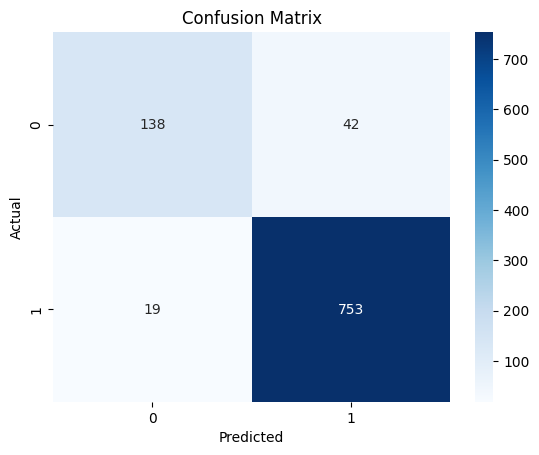

ROC Curve:


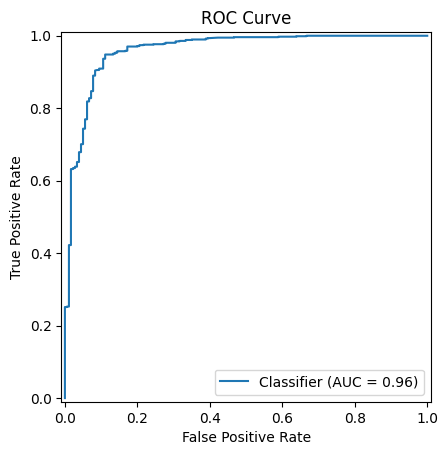

AUPRC Curve:


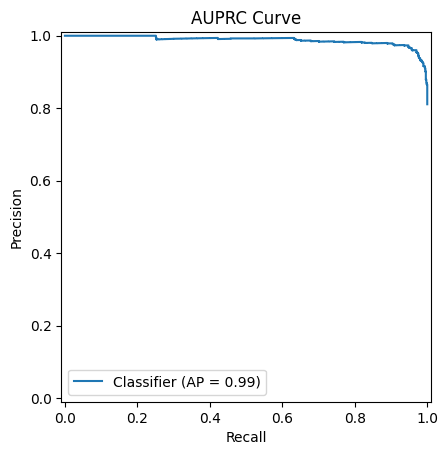

In [51]:
calc_metrics(final_model_lgbm)

In [52]:
calc_loss(final_model_lgbm)

Log Loss(Test): 0.1748348895206729
Log Loss(Train): 0.07584290223770751
Focal Loss (Test Set): 0.0210


In [53]:
save_model(final_model_lgbm, best_params, "lightgbm_bioactivity_model")

Model and metadata saved to saved_model/ml_models/


In [54]:
shap_plot(final_model_lgbm)

ExplainerError: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. This check failed because for one of the samples the sum of the SHAP values was 1.593145, while the model output was 1.958389. If this difference is acceptable you can set check_additivity=False to disable this check.

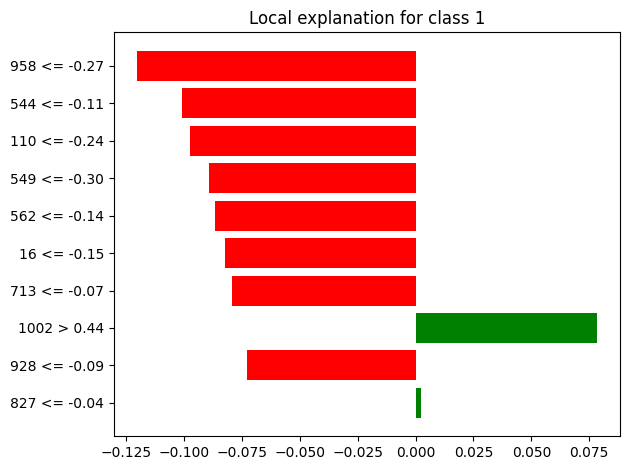


Feature contributions:
[('958 <= -0.27', -0.12034986063156065), ('544 <= -0.11', -0.10067013021332767), ('110 <= -0.24', -0.09739327898709257), ('549 <= -0.30', -0.08926928473619032), ('562 <= -0.14', -0.08662427457563089), ('16 <= -0.15', -0.08218372892646408), ('713 <= -0.07', -0.07906427909455827), ('1002 > 0.44', 0.07835519546345329), ('928 <= -0.09', -0.0727674306245851), ('827 <= -0.04', 0.0022965174279310258)]

Explanation as dict:
{1: [(958, -0.12034986063156065), (544, -0.10067013021332767), (110, -0.09739327898709257), (549, -0.08926928473619032), (562, -0.08662427457563089), (16, -0.08218372892646408), (713, -0.07906427909455827), (1002, 0.07835519546345329), (928, -0.0727674306245851), (827, 0.0022965174279310258)]}


In [55]:
lime_plot(final_model_lgbm)

##### CatBoost

In [59]:
import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def objective(trial):
    param = {
        "eval_metric": "AUC",
        "verbose": False,
        "boosting_type": "Plain",  # or "Ordered" for better quality but slower
        "depth": trial.suggest_int("depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "iterations": trial.suggest_int("iterations", 10, 200),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1),
        "random_strength": trial.suggest_float("random_strength", 0, 2),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "scale_pos_weight": scale_pos_weight,
        "thread_count": -1
    }
    model = CatBoostClassifier(**param)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)])
    preds = model.predict_proba(X_val)[:,1]
    auc = roc_auc_score(y_val, preds)

    return auc  # Optuna minimizes, so invert AUC

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=31)

print("Best trial:")
print(study.best_trial)
print("Best params:", study.best_params)

# Train final model with best params
best_params = study.best_params
best_params.update({
    "eval_metric": "AUC",
    "verbose": False,
    "boosting_type": "Plain"
})
final_model_cat = CatBoostClassifier(**best_params)
X_train_full=np.vstack([X_train, X_val])
y_train_full=np.concatenate([y_train, y_val])
final_model_cat.fit(X_train_full, y_train_full)
y_pred = final_model_cat.predict(X_test)
print("Final Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

[I 2025-11-21 07:26:42,707] A new study created in memory with name: no-name-84d47642-2475-4475-a2c3-d7dc2dc95d3a
[I 2025-11-21 07:26:43,658] Trial 0 finished with value: 0.7765104852031245 and parameters: {'depth': 3, 'learning_rate': 0.0010818738529633901, 'iterations': 172, 'l2_leaf_reg': 6.654744194817266, 'bagging_temperature': 0.7896412148371268, 'random_strength': 1.471171606689107, 'border_count': 227}. Best is trial 0 with value: 0.7765104852031245.
[I 2025-11-21 07:26:43,658] Trial 0 finished with value: 0.7765104852031245 and parameters: {'depth': 3, 'learning_rate': 0.0010818738529633901, 'iterations': 172, 'l2_leaf_reg': 6.654744194817266, 'bagging_temperature': 0.7896412148371268, 'random_strength': 1.471171606689107, 'border_count': 227}. Best is trial 0 with value: 0.7765104852031245.
[I 2025-11-21 07:26:45,111] Trial 1 finished with value: 0.8526192009407285 and parameters: {'depth': 5, 'learning_rate': 0.0033479172399176766, 'iterations': 193, 'l2_leaf_reg': 1.4946318

Best trial:
FrozenTrial(number=25, state=1, values=[0.9627698294929585], datetime_start=datetime.datetime(2025, 11, 21, 7, 27, 41, 782052), datetime_complete=datetime.datetime(2025, 11, 21, 7, 27, 45, 266090), params={'depth': 9, 'learning_rate': 0.14932921141248393, 'iterations': 180, 'l2_leaf_reg': 3.480449112144566, 'bagging_temperature': 0.2507397627884016, 'random_strength': 0.604701063685994, 'border_count': 175}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'depth': IntDistribution(high=10, log=False, low=3, step=1), 'learning_rate': FloatDistribution(high=0.3, log=True, low=0.001, step=None), 'iterations': IntDistribution(high=200, log=False, low=10, step=1), 'l2_leaf_reg': FloatDistribution(high=10.0, log=False, low=1.0, step=None), 'bagging_temperature': FloatDistribution(high=1.0, log=False, low=0.0, step=None), 'random_strength': FloatDistribution(high=2.0, log=False, low=0.0, step=None), 'border_count': IntDistribution(high=255, log=False, low=32,

Accuracy: 0.9317
Balanced Acc.: 0.8599
Cohen's Kappa: 0.7638
Precision: 0.9424
Recall: 0.9754
F1 Score: 0.9586
ROC-AUC: 0.9647
AUPRC: 0.9873
MCC: 0.7675
NPV: 0.8758
Specificity: 0.7444
Sensitivity: 0.9754
Informedness: 0.7198
DOR: 115.4485
Brier Score: 0.0497
********************
Confusion Matrix:


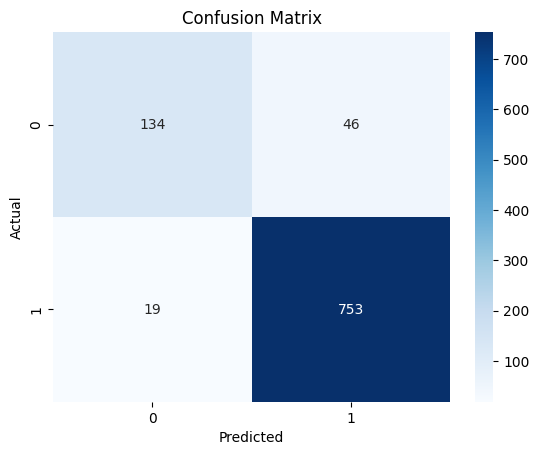

ROC Curve:


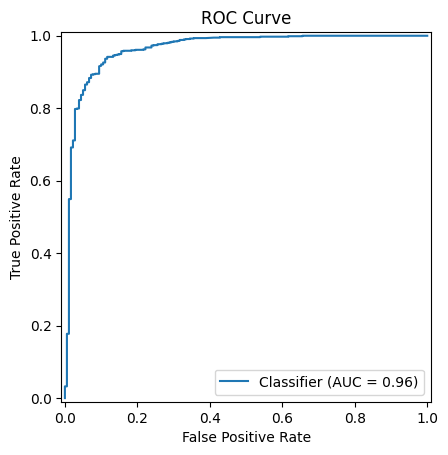

AUPRC Curve:


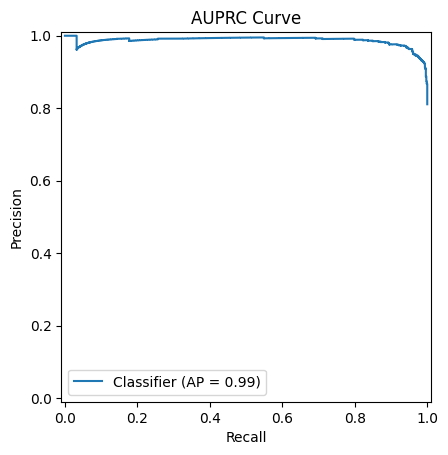

In [60]:
calc_metrics(final_model_cat)

In [ ]:
calc_loss(final_model_cat)

Log Loss(Test): 0.2190695273344371
Log Loss(Train): 0.011224370575528596
Focal Loss (Test Set): 0.0413


In [61]:
save_model(final_model_cat, best_params, "catboost_bioactivity_model")

Model and metadata saved to saved_model/ml_models/


 97%|=================== | 552/567 [00:19<00:00]       

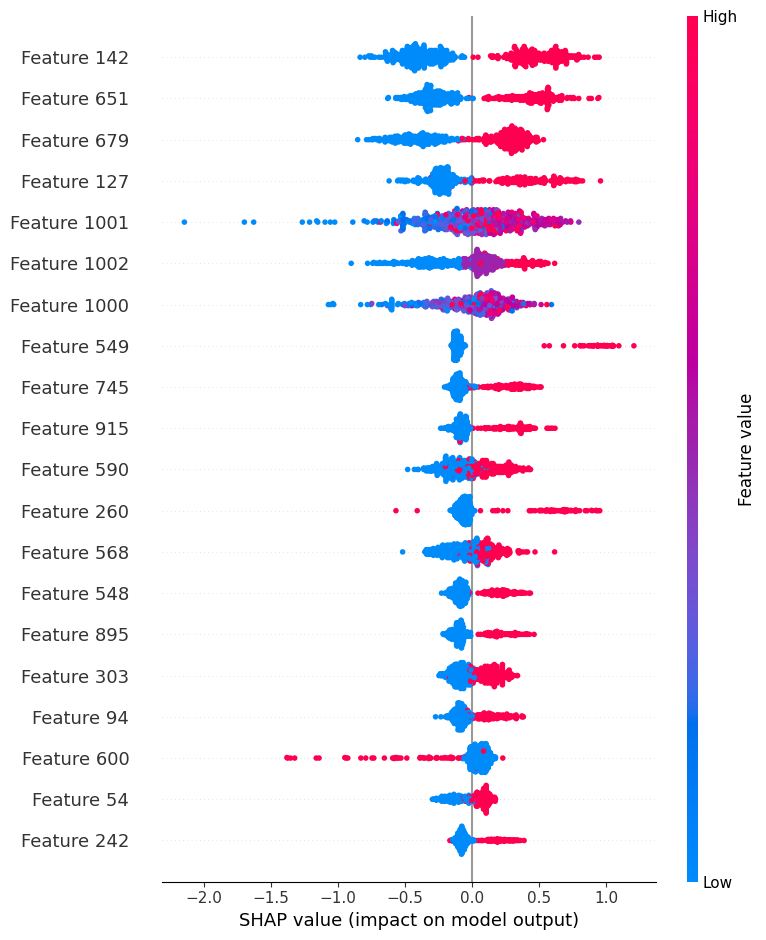

In [ ]:
shap_plot(final_model_cat) 

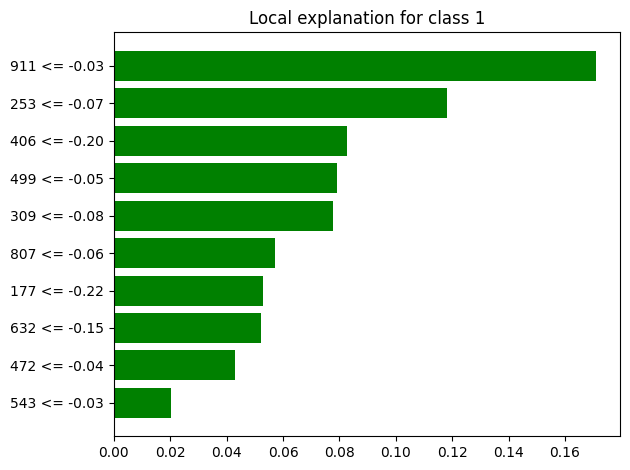


Feature contributions:
[('911 <= -0.03', 0.17096581388175838), ('253 <= -0.07', 0.11825085070906378), ('406 <= -0.20', 0.08251819396728871), ('499 <= -0.05', 0.07909110354423336), ('309 <= -0.08', 0.07757619640363134), ('807 <= -0.06', 0.0572646875301811), ('177 <= -0.22', 0.05273116837871044), ('632 <= -0.15', 0.05235679166408715), ('472 <= -0.04', 0.04306400610434662), ('543 <= -0.03', 0.020103541603138313)]

Explanation as dict:
{1: [(911, 0.17096581388175838), (253, 0.11825085070906378), (406, 0.08251819396728871), (499, 0.07909110354423336), (309, 0.07757619640363134), (807, 0.0572646875301811), (177, 0.05273116837871044), (632, 0.05235679166408715), (472, 0.04306400610434662), (543, 0.020103541603138313)]}


In [ ]:
lime_plot(final_model_cat)

##### ExtraTree Classifier

In [62]:
import optuna
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
from sklearn.model_selection import cross_val_score
import numpy as np

# Calculate class imbalance (if needed)

def objective(trial):
    """
    Objective function for Optuna to optimize ExtraTreesClassifier
    """
    
    param = {
        # Number of trees in the forest
        "n_estimators": trial.suggest_int("n_estimators", 10, 500),
        
        # Maximum depth of the tree
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        
        # Minimum samples required to split an internal node
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        
        # Minimum samples required at a leaf node
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        
        # Number of features to consider when looking for the best split
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None, 0.3, 0.5, 0.7, 1.0]),
        
        # Whether to use bootstrap samples
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        
        # --- CLASS IMBALANCE HANDLING ---
        # Option 1: Use automatic balancing
        "class_weight": trial.suggest_categorical("class_weight", ["balanced", "balanced_subsample", None]),
        
        # Option 2: Use fixed calculated weight (uncomment and comment out Option 1)
        # "class_weight": {0: 1.0, 1: scale_pos_weight},
        
        # Option 3: Tune the minority class weight (uncomment and comment out Option 1)
        # "class_weight": {0: 1.0, 1: trial.suggest_float("minority_weight", 1.0, 10.0)},
        
        # --- ADDITIONAL PARAMETERS ---
        # Minimum weighted fraction of samples required at leaf
        "min_weight_fraction_leaf": trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.1),
        
        # Maximum number of leaf nodes
        "max_leaf_nodes": trial.suggest_categorical("max_leaf_nodes", [None, 10, 20, 50, 100]),
        
        # Minimum impurity decrease for split
        "min_impurity_decrease": trial.suggest_float("min_impurity_decrease", 0.0, 0.2),
        
        # Complexity parameter for pruning
        "ccp_alpha": trial.suggest_float("ccp_alpha", 0.0, 0.1),
        
        # Maximum number of samples when bootstrap is True
        "max_samples": trial.suggest_float("max_samples", 0.5, 1.0) if trial.params.get("bootstrap", True) else None,
        
        # Quality of split criterion
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
        
        # Other settings
        "random_state": 42,
        "n_jobs": -1,  # Use all CPU cores
        "warm_start": False,
        "oob_score": False  # Out-of-bag score (only if bootstrap=True)
    }
    
    # Remove max_samples if bootstrap is False
    if not param["bootstrap"]:
        param.pop("max_samples", None)
    
    # Build and train model
    model = ExtraTreesClassifier(**param)
    model.fit(X_train, y_train)
    
    # Predict probabilities for AUC calculation
    preds_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, preds_proba)

    # Alternative: Use accuracy
    # preds = model.predict(X_test)
    # accuracy = accuracy_score(y_test, preds)
    # return 1.0 - accuracy
    
    # Alternative: Use F1 score
    # preds = model.predict(X_test)
    # f1 = f1_score(y_test, preds)
    # return 1.0 - f1
    
    return auc  # Optuna minimizes



# Create study and optimize
print("Starting hyperparameter optimization...")
study = optuna.create_study(
    direction="maximize",
    study_name="extratrees_optimization",
    sampler=optuna.samplers.TPESampler(seed=42)
)

# Run optimization
study.optimize(objective, n_trials=31, show_progress_bar=True)

# Print results
print("\n" + "="*50)
print("OPTIMIZATION RESULTS")
print("="*50)
print(f"Best trial: {study.best_trial.number}")
print(f"Best AUC: {1 - study.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# Train final model with best parameters
print("\n" + "="*50)
print("TRAINING FINAL MODEL")
print("="*50)

best_params = study.best_params.copy()
best_params.update({
    "random_state": 42,
    "n_jobs": -1
})


X_train_full=np.vstack([X_train, X_val])
y_train_full=np.concatenate([y_train, y_val])
    
final_model_et = ExtraTreesClassifier(**best_params)
final_model_et.fit(X_train_full, y_train_full)

# Evaluate final model
y_pred = final_model_et.predict(X_test)
y_pred_proba = final_model_et.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(f"\nFinal Model Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"  F1 Score: {f1_score(y_test, y_pred):.4f}")


print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature importance
print(f"\nTop 10 Most Important Features:")
feature_importance = final_model_et.feature_importances_
feature_names = X_train.columns if hasattr(X_train, 'columns') else [f"Feature_{i}" for i in range(X_train.shape[1])]
importance_df = sorted(zip(feature_names, feature_importance), key=lambda x: x[1], reverse=True)
for name, importance in importance_df[:10]:
    print(f"  {name}: {importance:.4f}")

# Optuna visualization (optional)
try:
    import plotly
    
    # Plot optimization history
    fig1 = optuna.visualization.plot_optimization_history(study)
    fig1.write_html("optuna_history.html")
    
    # Plot parameter importances
    fig2 = optuna.visualization.plot_param_importances(study)
    fig2.write_html("optuna_param_importances.html")
    
    # Plot parallel coordinate
    fig3 = optuna.visualization.plot_parallel_coordinate(study)
    fig3.write_html("optuna_parallel_coordinate.html")
    
    print("\nOptuna visualizations saved as HTML files!")
except ImportError:
    print("\nInstall plotly for visualizations: pip install plotly")

[I 2025-11-21 07:49:12,299] A new study created in memory with name: extratrees_optimization


Starting hyperparameter optimization...


Best trial: 0. Best value: 0.655787:   3%|▎         | 1/31 [00:00<00:12,  2.32it/s]

[I 2025-11-21 07:49:12,730] Trial 0 finished with value: 0.6557871601758266 and parameters: {'n_estimators': 193, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 0.3, 'bootstrap': True, 'class_weight': 'balanced', 'min_weight_fraction_leaf': 0.030424224295953775, 'max_leaf_nodes': 50, 'min_impurity_decrease': 0.058428929707043636, 'ccp_alpha': 0.03663618432936917, 'max_samples': 0.728034992108518, 'criterion': 'gini'}. Best is trial 0 with value: 0.6557871601758266.


Best trial: 0. Best value: 0.655787:   6%|▋         | 2/31 [00:01<00:20,  1.44it/s]

...

[I 2025-11-21 07:49:39,406] Trial 28 finished with value: 0.5 and parameters: {'n_estimators': 284, 'max_depth': 14, 'min_samples_split': 17, 'min_samples_leaf': 9, 'max_features': 1.0, 'bootstrap': False, 'class_weight': 'balanced_subsample', 'min_weight_fraction_leaf': 0.04933152550089419, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.18993798068667248, 'ccp_alpha': 0.009929662379259964, 'criterion': 'entropy'}. Best is trial 12 with value: 0.9210599994400426.


Best trial: 12. Best value: 0.92106:  97%|█████████▋| 30/31 [00:27<00:00,  1.40it/s]

[I 2025-11-21 07:49:39,845] Trial 29 finished with value: 0.6801768065627013 and parameters: {'n_estimators': 196, 'max_depth': 10, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 1.0, 'bootstrap': False, 'class_weight': 'balanced_subsample', 'min_weight_fraction_leaf': 0.03445325335318729, 'max_leaf_nodes': 50, 'min_impurity_decrease': 0.04874506886783428, 'ccp_alpha': 0.0293324097415871, 'criterion': 'entropy'}. Best is trial 12 with value: 0.9210599994400426.


Best trial: 12. Best value: 0.92106: 100%|██████████| 31/31 [00:27<00:00,  1.11it/s]



[I 2025-11-21 07:49:40,277] Trial 30 finished with value: 0.6557871601758266 and parameters: {'n_estimators': 217, 'max_depth': 6, 'min_samples_split': 14, 'min_samples_leaf': 10, 'max_features': 1.0, 'bootstrap': False, 'class_weight': 'balanced_subsample', 'min_weight_fraction_leaf': 0.02522667100282809, 'max_leaf_nodes': 20, 'min_impurity_decrease': 0.07584828149138885, 'ccp_alpha': 0.03836841861625133, 'criterion': 'entropy'}. Best is trial 12 with value: 0.9210599994400426.

OPTIMIZATION RESULTS
Best trial: 12
Best AUC: 0.0789

Best hyperparameters:
  n_estimators: 389
  max_depth: 13
  min_samples_split: 14
  min_samples_leaf: 10
  max_features: 1.0
  bootstrap: True
  class_weight: balanced_subsample
  min_weight_fraction_leaf: 0.0037761396449231474
  max_leaf_nodes: None
  min_impurity_decrease: 0.003704870037461153
  ccp_alpha: 0.001314031571780859
  max_samples: 0.8674912522476047
  criterion: gini

TRAINING FINAL MODEL

Final Model Performance:
  Accuracy: 0.8666
  ROC-AUC: 

Accuracy: 0.8666
Balanced Acc.: 0.8581
Cohen's Kappa: 0.6221
Precision: 0.9601
Recall: 0.8718
F1 Score: 0.9138
ROC-AUC: 0.9262
AUPRC: 0.9793
MCC: 0.6365
NPV: 0.6056
Specificity: 0.8444
Sensitivity: 0.8718
Informedness: 0.7162
DOR: 36.9033
Brier Score: 0.1044
********************
Confusion Matrix:


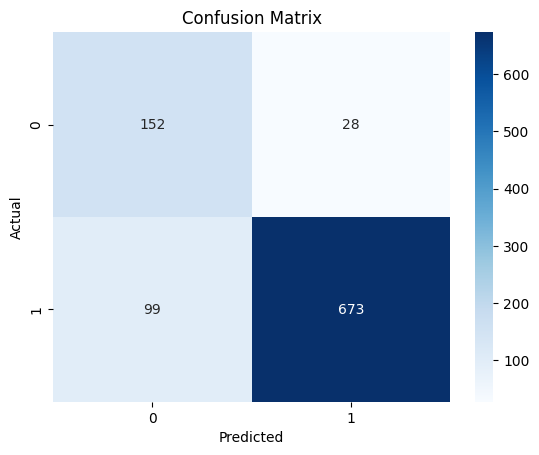

ROC Curve:


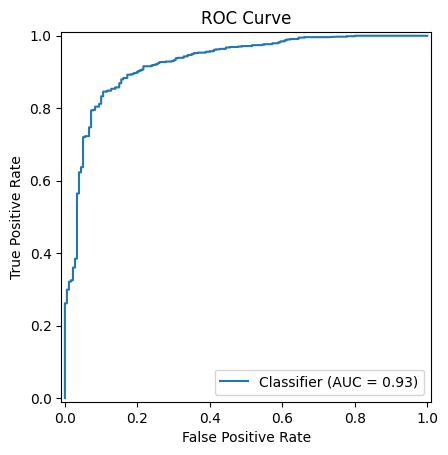

AUPRC Curve:


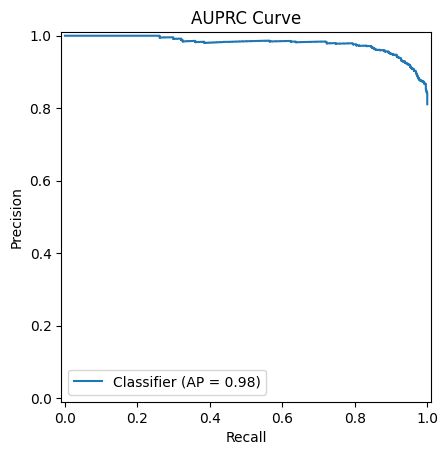

In [63]:
calc_metrics(final_model_et)

In [ ]:
calc_loss(final_model_et)

Log Loss(Test): 0.4425248219251295
Log Loss(Train): 0.4309275478829926
Log Loss(Train): 0.4309275478829926
Focal Loss (Test Set): 0.0274
Focal Loss (Test Set): 0.0274


In [64]:
save_model(final_model_et, best_params, "extratree_bioactivity_model")

Model and metadata saved to saved_model/ml_models/


 99%|===================| 1120/1134 [00:12<00:00]        

<Figure size 800x800 with 0 Axes>

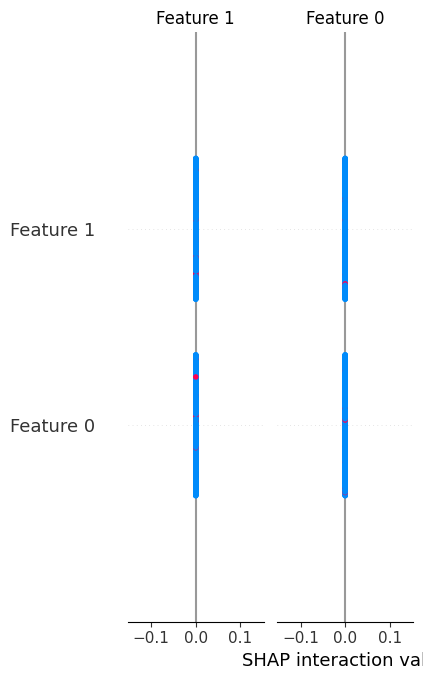

In [ ]:
shap_plot(final_model_et)

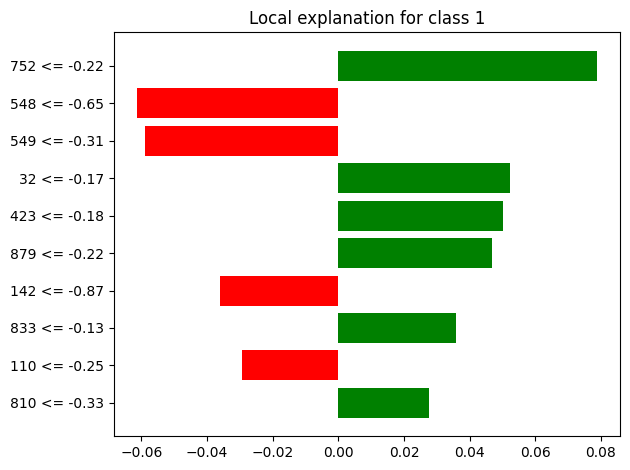


Feature contributions:
[('752 <= -0.22', 0.07881780828099061), ('548 <= -0.65', -0.06142204367133922), ('549 <= -0.31', -0.05902737443982358), ('32 <= -0.17', 0.05224565741352879), ('423 <= -0.18', 0.05026851430397369), ('879 <= -0.22', 0.046751170472080036), ('142 <= -0.87', -0.036060983243071575), ('833 <= -0.13', 0.03593766434248116), ('110 <= -0.25', -0.0292310590164007), ('810 <= -0.33', 0.027490413079199926)]

Explanation as dict:
{1: [(752, 0.07881780828099061), (548, -0.06142204367133922), (549, -0.05902737443982358), (32, 0.05224565741352879), (423, 0.05026851430397369), (879, 0.046751170472080036), (142, -0.036060983243071575), (833, 0.03593766434248116), (110, -0.0292310590164007), (810, 0.027490413079199926)]}


In [ ]:
lime_plot(final_model_et)

#### CNN 

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [17]:
# Calculate class weights for imbalance
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
class_weights = torch.tensor([1.0, neg_count / pos_count], dtype=torch.float32).to(device)
print(f"Class imbalance ratio: {neg_count / pos_count:.2f}:1")

Class imbalance ratio: 0.24:1


In [18]:
class CNN1D(nn.Module):
    """
    1D CNN for tabular data classification
    """
    def __init__(self, input_size, trial):
        super(CNN1D, self).__init__()
        
        # Hyperparameters from Optuna
        n_conv_layers = trial.suggest_int("n_conv_layers", 1, 3)
        n_fc_layers = trial.suggest_int("n_fc_layers", 1, 3)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5, log=True)
        
        # Build convolutional layers
        conv_layers = []
        in_channels = 1
        current_size = input_size
        
        for i in range(n_conv_layers):
            out_channels = trial.suggest_int(f"conv_{i}_out_channels", 32, 128, step=32)
            kernel_size = trial.suggest_int(f"conv_{i}_kernel_size", 3, 5, step=2)
            
            conv_layers.append(nn.Conv1d(in_channels, out_channels, kernel_size, padding=kernel_size//2))
            conv_layers.append(nn.BatchNorm1d(out_channels))
            conv_layers.append(nn.ReLU())
            conv_layers.append(nn.Dropout(dropout_rate))
            
            # Optional pooling
            if trial.suggest_categorical(f"conv_{i}_pooling", [True, False]):
                pool_size = trial.suggest_int(f"conv_{i}_pool_size", 2, 3)
                conv_layers.append(nn.MaxPool1d(pool_size))
                current_size = current_size // pool_size
            
            in_channels = out_channels
        
        self.conv_block = nn.Sequential(*conv_layers)
        
        # Calculate flattened size
        flattened_size = out_channels * current_size
        
        # Build fully connected layers
        fc_layers = []
        prev_size = flattened_size
        
        for i in range(n_fc_layers):
            fc_size = trial.suggest_int(f"fc_{i}_size", 64, 256, log=True)
            fc_layers.append(nn.Linear(prev_size, fc_size))
            fc_layers.append(nn.ReLU())
            fc_layers.append(nn.Dropout(dropout_rate))
            prev_size = fc_size
        
        # Output layer
        fc_layers.append(nn.Linear(prev_size, 2))
        
        self.fc_block = nn.Sequential(*fc_layers)
    
    def forward(self, x):
        x = x.unsqueeze(1)  # Add channel dimension: (batch, features) -> (batch, 1, features)
        x = self.conv_block(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc_block(x)
        return x

In [19]:
class CNN2D(nn.Module):
    """
    2D CNN for image-like data classification
    Assumes input is reshaped to (batch, channels, height, width)
    """
    def __init__(self, input_channels, input_height, input_width, trial):
        super(CNN2D, self).__init__()
        
        # Hyperparameters from Optuna
        n_conv_layers = trial.suggest_int("n_conv_layers", 2, 5)
        n_fc_layers = trial.suggest_int("n_fc_layers", 1, 3)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5, step=0.1)
        
        # Build convolutional layers
        conv_layers = []
        in_channels = input_channels
        current_h, current_w = input_height, input_width
        
        for i in range(n_conv_layers):
            out_channels = trial.suggest_int(f"conv_{i}_out_channels", 16, 128, step=16)
            kernel_size = trial.suggest_int(f"conv_{i}_kernel_size", 3, 7, step=2)
            
            conv_layers.append(nn.Conv2d(in_channels, out_channels, kernel_size, padding=kernel_size//2))
            conv_layers.append(nn.BatchNorm2d(out_channels))
            conv_layers.append(nn.ReLU())
            conv_layers.append(nn.Dropout2d(dropout_rate))
            
            # Pooling
            if trial.suggest_categorical(f"conv_{i}_pooling", [True, False]):
                pool_size = trial.suggest_int(f"conv_{i}_pool_size", 2, 3)
                conv_layers.append(nn.MaxPool2d(pool_size))
                current_h = current_h // pool_size
                current_w = current_w // pool_size
            
            in_channels = out_channels
        
        self.conv_block = nn.Sequential(*conv_layers)
        
        # Calculate flattened size
        flattened_size = out_channels * current_h * current_w
        
        # Build fully connected layers
        fc_layers = []
        prev_size = flattened_size
        
        for i in range(n_fc_layers):
            fc_size = trial.suggest_int(f"fc_{i}_size", 64, 512, step=64)
            fc_layers.append(nn.Linear(prev_size, fc_size))
            fc_layers.append(nn.ReLU())
            fc_layers.append(nn.Dropout(dropout_rate))
            prev_size = fc_size
        
        # Output layer
        fc_layers.append(nn.Linear(prev_size, 2))
        
        self.fc_block = nn.Sequential(*fc_layers)
    
    def forward(self, x):
        x = self.conv_block(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc_block(x)
        return x

In [23]:

def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    
    for batch_X, batch_y in dataloader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    
    return total_loss / len(dataloader)


def evaluate(model, dataloader, device):
    """Evaluate model"""
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for batch_X, batch_y in dataloader:
            batch_X = batch_X.to(device)
            outputs = model(batch_X)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)
            
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_y.numpy())
    
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


In [20]:
def objective_1d(trial):
    """
    Objective function for 1D CNN (for tabular data)
    """
    
    # Prepare data
    X_train_tensor = torch.FloatTensor(X_train.values if hasattr(X_train, 'values') else X_train)
    y_train_tensor = torch.LongTensor(y_train.values if hasattr(y_train, 'values') else y_train)
    X_val_tensor = torch.FloatTensor(X_val.values if hasattr(X_val, 'values') else X_val)
    y_val_tensor = torch.LongTensor(y_val.values if hasattr(y_val, 'values') else y_val)
    X_test_tensor = torch.FloatTensor(X_test.values if hasattr(X_test, 'values') else X_test)
    y_test_tensor = torch.LongTensor(y_test.values if hasattr(y_test, 'values') else y_test)
    
    # Hyperparameters
    batch_size = trial.suggest_categorical("batch_size", [32, 64])
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    n_epochs = 30
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "AdamW", "RMSprop"])
    
    # Create dataloaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Create model
    input_size = X_train_tensor.shape[1]
    model = CNN1D(input_size, trial).to(device)
    
    # Loss function with class weights
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    
    
    # Optimizer
    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    elif optimizer_name == "AdamW":
        optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    else:  # RMSprop
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    
    # Learning rate scheduler
    use_scheduler = trial.suggest_categorical("use_scheduler", [True, False])
    if use_scheduler:
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
    
    # Training loop
    best_auc = 0
    patience_counter = 0
    early_stopping_patience = 10
    
    for epoch in range(n_epochs):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Evaluate
        y_true, y_pred, y_prob = evaluate(model, val_loader, device)
        auc = roc_auc_score(y_true, y_prob)
        
        # Learning rate scheduling
        if use_scheduler:
            scheduler.step(train_loss)
        
        # Early stopping
        if auc > best_auc:
            best_auc = auc
            patience_counter = 0
        else:
            patience_counter += 1
        
        if patience_counter >= early_stopping_patience:
            break
        
        # Report to Optuna for pruning
        trial.report(auc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    return best_auc

##### 1d cnn

In [24]:
# Run optimization
import optuna
print("Starting CNN hyperparameter optimization...")
print("="*60)

# Choose which objective to use
study = optuna.create_study(
    direction="minimize",
    study_name="cnn_optimization",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)
)

# Optimize (use objective_1d for tabular data, objective_2d for images)
study.optimize(objective_1d, n_trials=31, show_progress_bar=True)

# Print results
print("\n" + "="*60)
print("OPTIMIZATION RESULTS")
print("="*60)
print(f"Best trial: {study.best_trial.number}")
print(f"Best AUC: {1 - study.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# Train final model with best parameters
print("\n" + "="*60)
print("TRAINING FINAL MODEL")
print("="*60)

best_params = study.best_params

# Recreate best trial for model architecture
best_trial = study.best_trial

# Prepare data
X_train_full=np.vstack([X_train, X_val])
y_train_full=np.concatenate([y_train, y_val])
X_train_tensor = torch.FloatTensor(X_train_full)
y_train_tensor = torch.LongTensor(y_train_full)
X_test_tensor = torch.FloatTensor(X_test.values if hasattr(X_test, 'values') else X_test)
y_test_tensor = torch.LongTensor(y_test.values if hasattr(y_test, 'values') else y_test)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = best_params['batch_size']
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Create final model
input_size = X_train_tensor.shape[1]
final_model = CNN1D(input_size, best_trial).to(device)

# Train final model
criterion = nn.CrossEntropyLoss(weight=class_weights)

if best_params['optimizer'] == "Adam":
    optimizer = optim.Adam(final_model.parameters(), lr=best_params['learning_rate'], 
                          weight_decay=best_params['weight_decay'])
elif best_params['optimizer'] == "AdamW":
    optimizer = optim.AdamW(final_model.parameters(), lr=best_params['learning_rate'], 
                           weight_decay=best_params['weight_decay'])
else:
    optimizer = optim.RMSprop(final_model.parameters(), lr=best_params['learning_rate'],  
                         weight_decay=best_params['weight_decay'])

for epoch in range(30):
    train_loss = train_epoch(final_model, train_loader, criterion, optimizer, device)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/30, Loss: {train_loss:.4f}")

# Final evaluation
y_true, y_pred, y_prob = evaluate(final_model, test_loader, device)

print(f"\nFinal Model Performance:")
print(f"  Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_true, y_prob):.4f}")
print(f"  F1 Score: {f1_score(y_true, y_pred):.4f}")

from sklearn.metrics import classification_report, confusion_matrix
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))
print(f"\nClassification Report:")
print(classification_report(y_true, y_pred))

# Save model
torch.save(final_model.state_dict(), 'best_cnn_model.pth')
print("\nModel saved as 'best_cnn_model.pth'")

[I 2025-11-21 09:05:26,148] A new study created in memory with name: cnn_optimization


Starting CNN hyperparameter optimization...


Best trial: 0. Best value: 0.921518:   3%|▎         | 1/31 [00:10<05:22, 10.76s/it]

[I 2025-11-21 09:05:36,904] Trial 0 finished with value: 0.9215184645966906 and parameters: {'batch_size': 64, 'learning_rate': 0.000291063591313307, 'weight_decay': 6.251373574521755e-05, 'optimizer': 'Adam', 'n_conv_layers': 3, 'n_fc_layers': 2, 'dropout_rate': 0.31255143181676115, 'conv_0_out_channels': 32, 'conv_0_kernel_size': 5, 'conv_0_pooling': True, 'conv_0_pool_size': 2, 'conv_1_out_channels': 32, 'conv_1_kernel_size': 3, 'conv_1_pooling': True, 'conv_1_pool_size': 2, 'conv_2_out_channels': 96, 'conv_2_kernel_size': 3, 'conv_2_pooling': False, 'fc_0_size': 120, 'fc_1_size': 190, 'use_scheduler': False}. Best is trial 0 with value: 0.9215184645966906.


Best trial: 1. Best value: 0.920731:   6%|▋         | 2/31 [00:24<05:57, 12.32s/it]

...

[I 2025-11-21 09:11:25,937] Trial 28 finished with value: 0.914179522356301 and parameters: {'batch_size': 64, 'learning_rate': 0.00010102955572424535, 'weight_decay': 0.0008432732955441743, 'optimizer': 'Adam', 'n_conv_layers': 3, 'n_fc_layers': 1, 'dropout_rate': 0.4996431941641488, 'conv_0_out_channels': 128, 'conv_0_kernel_size': 3, 'conv_0_pooling': True, 'conv_0_pool_size': 3, 'conv_1_out_channels': 64, 'conv_1_kernel_size': 3, 'conv_1_pooling': False, 'conv_2_out_channels': 32, 'conv_2_kernel_size': 3, 'conv_2_pooling': False, 'fc_0_size': 138, 'use_scheduler': False}. Best is trial 26 with value: 0.8974227958675141.


Best trial: 26. Best value: 0.897423:  97%|█████████▋| 30/31 [06:09<00:11, 11.06s/it]

[I 2025-11-21 09:11:35,524] Trial 29 finished with value: 0.9194011255144608 and parameters: {'batch_size': 64, 'learning_rate': 0.0001138953480076205, 'weight_decay': 0.000850088685083961, 'optimizer': 'Adam', 'n_conv_layers': 3, 'n_fc_layers': 1, 'dropout_rate': 0.48164086960695207, 'conv_0_out_channels': 128, 'conv_0_kernel_size': 5, 'conv_0_pooling': True, 'conv_0_pool_size': 3, 'conv_1_out_channels': 64, 'conv_1_kernel_size': 3, 'conv_1_pooling': False, 'conv_2_out_channels': 32, 'conv_2_kernel_size': 3, 'conv_2_pooling': False, 'fc_0_size': 112, 'use_scheduler': False}. Best is trial 26 with value: 0.8974227958675141.


Best trial: 26. Best value: 0.897423: 100%|██████████| 31/31 [06:18<00:00, 12.22s/it]



[I 2025-11-21 09:11:45,081] Trial 30 finished with value: 0.9192681356216926 and parameters: {'batch_size': 64, 'learning_rate': 8.038437951279324e-05, 'weight_decay': 0.0009898963513775172, 'optimizer': 'Adam', 'n_conv_layers': 3, 'n_fc_layers': 1, 'dropout_rate': 0.4019959147176979, 'conv_0_out_channels': 128, 'conv_0_kernel_size': 3, 'conv_0_pooling': True, 'conv_0_pool_size': 3, 'conv_1_out_channels': 32, 'conv_1_kernel_size': 3, 'conv_1_pooling': False, 'conv_2_out_channels': 32, 'conv_2_kernel_size': 3, 'conv_2_pooling': False, 'fc_0_size': 138, 'use_scheduler': False}. Best is trial 26 with value: 0.8974227958675141.

OPTIMIZATION RESULTS
Best trial: 26
Best AUC: 0.1026

Best hyperparameters:
  batch_size: 64
  learning_rate: 9.154974422549072e-05
  weight_decay: 3.974413799446102e-05
  optimizer: Adam
  n_conv_layers: 3
  n_fc_layers: 1
  dropout_rate: 0.38153498503932975
  conv_0_out_channels: 64
  conv_0_kernel_size: 3
  conv_0_pooling: True
  conv_0_pool_size: 3
  conv_1_out

Accuracy: 0.8519
Balanced Acc.: 0.6190
Precision: 0.8494
Recall: 0.9935
F1 Score: 0.9158
ROC-AUC: 0.9205
MCC: 0.4217
NPV: 0.8980
AUPRC: 0.9753
Specificity: 0.2444
Sensitivity: 0.9935
Informedness: 0.2380
DOR: 49.6294
Brier Score: 0.1129
********************
Confusion Matrix:


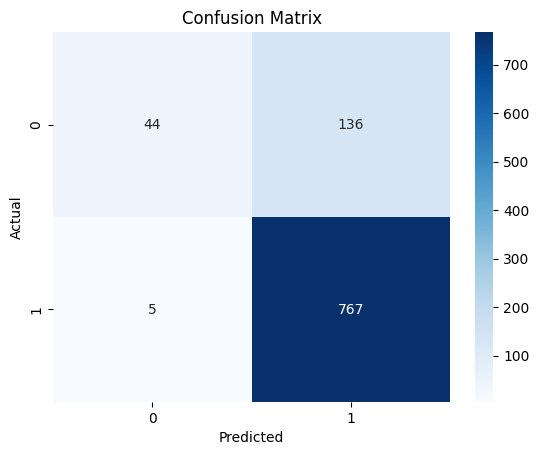

ROC Curve:


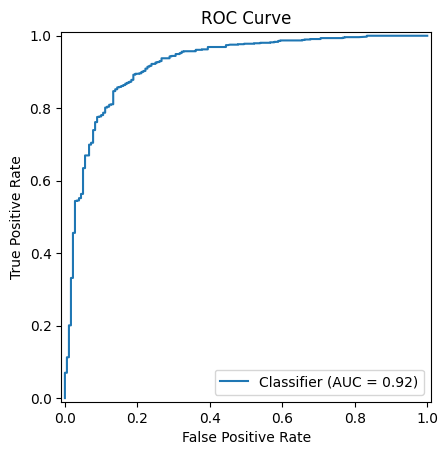

AUPRC Curve:


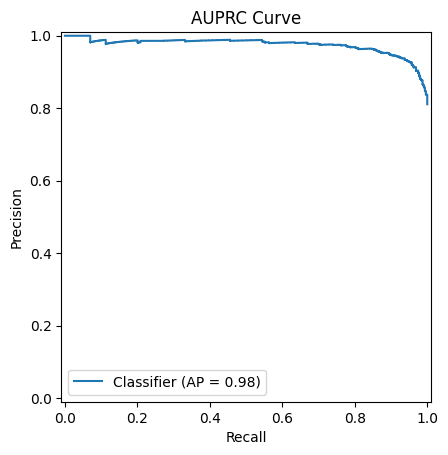

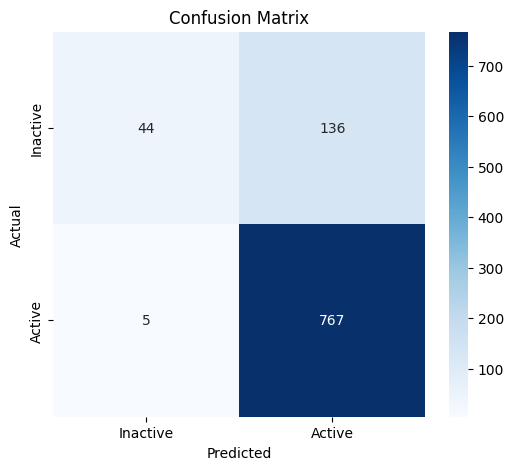

              precision    recall  f1-score   support

           0       0.90      0.24      0.38       180
           1       0.85      0.99      0.92       772

    accuracy                           0.85       952
   macro avg       0.87      0.62      0.65       952
weighted avg       0.86      0.85      0.82       952



In [25]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Robust confusion matrix plot that works for sklearn-like models or the trained PyTorch CNN
import matplotlib.pyplot as plt

# Get predictions and true labels
if hasattr(final_model, "predict") and 'X_test' in globals():
    y_pred_local = final_model.predict(X_test)
    y_true_local = y_test.values if hasattr(y_test, "values") else y_test
elif 'y_pred' in globals() and 'y_true' in globals() and 'y_pred' in globals():
    y_pred_local = y_pred
    y_true_local = y_true
    y_prob_local = y_prob
else:
    # Fall back to using the PyTorch model and test_loader
    final_model.eval()
    preds, trues, probs = [], [], []
    with torch.no_grad():
        for bx, by in test_loader:
            bx = bx.to(device)
            out = final_model(bx)
            pred = torch.argmax(out, dim=1).cpu().numpy()
            prob = torch.softmax(out, dim=1)[:, 1]
            preds.append(pred)
            trues.append(by.numpy())
            probs.append(prob)
    y_pred_local = np.concatenate(preds)
    y_true_local = np.concatenate(trues)
    y_prob_local = np.concatenate(probs)
# Plot
accuracy = accuracy_score(y_true_local, y_pred_local)
balanced_acc = balanced_accuracy_score(y_true_local, y_pred_local)
precision = precision_score(y_true_local, y_pred_local)
recall = recall_score(y_true_local, y_pred_local)  # This is also Sensitivity
f1 = f1_score(y_true_local, y_pred_local)
roc_auc = roc_auc_score(y_true_local, y_prob_local)
mcc = matthews_corrcoef(y_true_local, y_pred_local)
auprc = average_precision_score(y_true_local, y_prob_local)  # Area Under Precision-Recall Curve
kappa = cohen_kappa_score(y_true_local, y_pred_local, weights='quadratic')

# For Specificity: Derive from confusion matrix
cm = confusion_matrix(y_true_local, y_pred_local)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
npv = tn / (tn + fn) 
sensitivity = recall  # Same as recall
informedness = sensitivity + specificity - 1

dor = (tp * tn) / (fn * fp) if fp != 0 and fn != 0 else float('inf')

brier = brier_score_loss(y_true_local, y_prob_local)

# Step 3: Print or store results (e.g., to fill your table)
print(f"Accuracy: {accuracy:.4f}")
print(f"Balanced Acc.: {balanced_acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"NPV: {npv:.4f}")
print(f"AUPRC: {auprc:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print("Informedness: {:.4f}".format(informedness))
print(f"DOR: {dor:.4f}")
print(f"Brier Score: {brier:.4f}")

print("********************")
print("Confusion Matrix:")
plot_confusion_matrix(y_true_local, y_pred_local)

print("ROC Curve:")
plot_roc_curve(y_true_local, y_prob_local)

print("AUPRC Curve:")
plot_auprc_curve(y_true_local, y_prob_local)

cm = confusion_matrix(y_true_local, y_pred_local)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Inactive','Active'], yticklabels=['Inactive','Active'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
print(classification_report(y_true_local, y_pred_local))

##### 2d

In [ ]:
# # Run optimization
# print("Starting CNN hyperparameter optimization...")
# print("="*60)

# # Choose which objective to use
# study = optuna.create_study(
#     direction="minimize",
#     study_name="cnn_optimization",
#     sampler=optuna.samplers.TPESampler(seed=42),
#     pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)
# )

# # Optimize (use objective_1d for tabular data, objective_2d for images)
# study.optimize(objective_2d, n_trials=50, show_progress_bar=True)

# # Print results
# print("\n" + "="*60)
# print("OPTIMIZATION RESULTS")
# print("="*60)
# print(f"Best trial: {study.best_trial.number}")
# print(f"Best AUC: {1 - study.best_value:.4f}")
# print(f"\nBest hyperparameters:")
# for key, value in study.best_params.items():
#     print(f"  {key}: {value}")

# # Train final model with best parameters
# print("\n" + "="*60)
# print("TRAINING FINAL MODEL")
# print("="*60)

# best_params = study.best_params

# # Recreate best trial for model architecture
# best_trial = study.best_trial

# # Prepare data
# X_train_tensor = torch.FloatTensor(X_train.values if hasattr(X_train, 'values') else X_train)
# y_train_tensor = torch.LongTensor(y_train.values if hasattr(y_train, 'values') else y_train)
# X_test_tensor = torch.FloatTensor(X_test.values if hasattr(X_test, 'values') else X_test)
# y_test_tensor = torch.LongTensor(y_test.values if hasattr(y_test, 'values') else y_test)

# train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
# test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# batch_size = best_params['batch_size']
# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# # Create final model
# input_size = X_train_tensor.shape[1]
# final_model = CNN1D(input_size, best_trial).to(device)

# # Train final model
# criterion = nn.CrossEntropyLoss(weight=class_weights if best_params['use_class_weights'] else None)

# if best_params['optimizer'] == "Adam":
#     optimizer = optim.Adam(final_model.parameters(), lr=best_params['learning_rate'], 
#                           weight_decay=best_params['weight_decay'])
# elif best_params['optimizer'] == "AdamW":
#     optimizer = optim.AdamW(final_model.parameters(), lr=best_params['learning_rate'], 
#                            weight_decay=best_params['weight_decay'])
# else:
#     optimizer = optim.SGD(final_model.parameters(), lr=best_params['learning_rate'], 
#                          momentum=best_params.get('momentum', 0.9), 
#                          weight_decay=best_params['weight_decay'])

# for epoch in range(best_params['n_epochs']):
#     train_loss = train_epoch(final_model, train_loader, criterion, optimizer, device)
#     if (epoch + 1) % 10 == 0:
#         print(f"Epoch {epoch+1}/{best_params['n_epochs']}, Loss: {train_loss:.4f}")

# # Final evaluation
# y_true, y_pred, y_prob = evaluate(final_model, test_loader, device)

# print(f"\nFinal Model Performance:")
# print(f"  Accuracy: {accuracy_score(y_true, y_pred):.4f}")
# print(f"  ROC-AUC: {roc_auc_score(y_true, y_prob):.4f}")
# print(f"  F1 Score: {f1_score(y_true, y_pred):.4f}")

# from sklearn.metrics import classification_report, confusion_matrix
# print(f"\nConfusion Matrix:")
# print(confusion_matrix(y_true, y_pred))
# print(f"\nClassification Report:")
# print(classification_report(y_true, y_pred))

# # Save model
# torch.save(final_model.state_dict(), 'best_cnn_model_2d.pth')
# print("\nModel saved as 'best_cnn_model_2d.pth'")

In [ ]:
# from sklearn.metrics import confusion_matrix, classification_report
# import seaborn as sns

# # Robust confusion matrix plot that works for sklearn-like models or the trained PyTorch CNN
# import matplotlib.pyplot as plt

# # Get predictions and true labels
# if hasattr(final_model, "predict") and 'X_test' in globals():
#     y_pred_local = final_model.predict(X_test)
#     y_true_local = y_test.values if hasattr(y_test, "values") else y_test
# elif 'y_pred' in globals() and 'y_true' in globals() and 'y_pred' in globals():
#     y_pred_local = y_pred
#     y_true_local = y_true
#     y_prob_local = y_prob
# else:
#     # Fall back to using the PyTorch model and test_loader
#     final_model.eval()
#     preds, trues, probs = [], [], []
#     with torch.no_grad():
#         for bx, by in test_loader:
#             bx = bx.to(device)
#             out = final_model(bx)
#             pred = torch.argmax(out, dim=1).cpu().numpy()
#             prob = torch.softmax(out, dim=1)[:, 1]
#             preds.append(pred)
#             trues.append(by.numpy())
#             probs.append(prob)
#     y_pred_local = np.concatenate(preds)
#     y_true_local = np.concatenate(trues)
#     y_prob_local = np.concatenate(probs)
# # Plot
# accuracy = accuracy_score(y_true_local, y_pred_local)
# balanced_acc = balanced_accuracy_score(y_true_local, y_pred_local)
# precision = precision_score(y_true_local, y_pred_local)
# recall = recall_score(y_true_local, y_pred_local)  # This is also Sensitivity
# f1 = f1_score(y_true_local, y_pred_local)
# roc_auc = roc_auc_score(y_true_local, y_prob_local)
# mcc = matthews_corrcoef(y_true_local, y_pred_local)
# auprc = average_precision_score(y_true_local, y_prob_local)  # Area Under Precision-Recall Curve

# # For Specificity: Derive from confusion matrix
# cm = confusion_matrix(y_true_local, y_pred_local)
# tn, fp, fn, tp = cm.ravel()
# specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
# sensitivity = recall  # Same as recall

# # Step 3: Print or store results (e.g., to fill your table)
# print(f"Accuracy: {accuracy:.4f}")
# print(f"Balanced Acc.: {balanced_acc:.4f}")
# print(f"Precision: {precision:.4f}")
# print(f"Recall: {recall:.4f}")
# print(f"F1 Score: {f1:.4f}")
# print(f"ROC-AUC: {roc_auc:.4f}")
# print(f"MCC: {mcc:.4f}")
# print(f"Specificity: {specificity:.4f}")
# print(f"Sensitivity: {sensitivity:.4f}")
# print(f"AUPRC: {auprc:.4f}")
# cm = confusion_matrix(y_true_local, y_pred_local)
# plt.figure(figsize=(6,5))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Inactive','Active'], yticklabels=['Inactive','Active'])
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.title('Confusion Matrix')
# plt.show()

# # Print classification report
# print(classification_report(y_true_local, y_pred_local))

 #### SVN 

In [38]:
import optuna
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# ============================================================================
# SVM (Support Vector Machine) Optimization
# ============================================================================

print("="*70)
print("SVM HYPERPARAMETER OPTIMIZATION")
print("="*70)



# Calculate class weights for imbalance
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"Class imbalance ratio: {scale_pos_weight:.2f}:1\n")

def objective_svm(trial):
    param = {
        # Kernel type
        "kernel": trial.suggest_categorical("kernel", ["linear", "rbf", "poly", "sigmoid"]),
        
        # Regularization parameter
        "C": trial.suggest_float("C", 1e-3, 1e-2, log=True),
        
        # Kernel coefficient (for rbf, poly, sigmoid)
        "gamma": trial.suggest_categorical("gamma", ["scale", "auto"]),
        
        # Degree for polynomial kernel
        "degree": trial.suggest_int("degree", 2, 5) if trial.params.get("kernel") == "poly" else 3,
        
        # Class weight for imbalance
        "class_weight": trial.suggest_categorical("class_weight", ["balanced"]),
        
        # Probability estimates (needed for ROC-AUC)
        "probability": True,
        
        # Tolerance for stopping criterion
        "tol": trial.suggest_float("tol", 1e-5, 1e-2, log=True),
        
        # Maximum iterations
        "max_iter": trial.suggest_int("max_iter", 100, 1000, step=100),
        
        # Shrinking heuristic
        "shrinking": trial.suggest_categorical("shrinking", [True, False])
    }
    
    # Remove degree if not polynomial kernel
    if param["kernel"] != "poly":
        param.pop("degree", None)
    
    model = SVC(**param)
    model.fit(X_train, y_train)
    
    # Predict probabilities for AUC
    preds_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, preds_proba)
    
    return auc  # Optuna minimizes, so invert AUC

# Create and run study
study_svm = optuna.create_study(
    direction="maximize",
    study_name="svm_optimization",
    sampler=optuna.samplers.TPESampler(seed=42)
)

print("Starting SVM optimization...")
study_svm.optimize(objective_svm, n_trials=31, show_progress_bar=True)

print("\n" + "="*70)
print("SVM OPTIMIZATION RESULTS")
print("="*70)
print(f"Best trial: {study_svm.best_trial.number}")
print(f"Best AUC: {1 - study_svm.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study_svm.best_params.items():
    print(f"  {key}: {value}")

# Train final SVM model with best params
print("\n" + "="*70)
print("TRAINING FINAL SVM MODEL")
print("="*70)

best_params_svm = study_svm.best_params.copy()
best_params_svm.update({
    "probability": True,
    "random_state": 42
})

final_model_svm = SVC(**best_params_svm)
final_model_svm.fit(X_train_full, y_train_full)

# Evaluate on test set
y_pred_svm = final_model_svm.predict(X_test)
y_pred_proba_svm = final_model_svm.predict_proba(X_test)[:, 1]

print(f"\nFinal SVM Model Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_pred_proba_svm):.4f}")

print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

[I 2025-11-21 09:52:26,531] A new study created in memory with name: svm_optimization


SVM HYPERPARAMETER OPTIMIZATION
Class imbalance ratio: 0.24:1

Starting SVM optimization...


  0%|          | 0/31 [00:00<?, ?it/s]e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=700).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
Best trial: 0. Best value: 0.589838:   3%|▎         | 1/31 [00:10<05:01, 10.04s/it]

[I 2025-11-21 09:52:36,574] Trial 0 finished with value: 0.5898381722989052 and parameters: {'kernel': 'rbf', 'C': 0.001432249371823025, 'gamma': 'scale', 'class_weight': 'balanced', 'tol': 0.003967605077052989, 'max_iter': 700, 'shrinking': True}. Best is trial 0 with value: 0.5898381722989052.


e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=300).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
Best trial: 1. Best value: 0.797722:   6%|▋         | 2/31 [00:15<03:26,  7.10s/it]

...

[I 2025-11-21 09:57:23,997] Trial 29 finished with value: 0.5892432175154688 and parameters: {'kernel': 'rbf', 'C': 0.0030713990506156742, 'gamma': 'scale', 'class_weight': 'balanced', 'tol': 0.0051463646467119414, 'max_iter': 700, 'shrinking': False}. Best is trial 13 with value: 0.922942856342918.


e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
Best trial: 13. Best value: 0.922943: 100%|██████████| 31/31 [05:09<00:00,  9.98s/it]


[I 2025-11-21 09:57:36,011] Trial 30 finished with value: 0.9187431755186607 and parameters: {'kernel': 'linear', 'C': 0.002597055152470495, 'gamma': 'auto', 'class_weight': 'balanced', 'tol': 0.003481899701354786, 'max_iter': 1000, 'shrinking': False}. Best is trial 13 with value: 0.922942856342918.

SVM OPTIMIZATION RESULTS
Best trial: 13
Best AUC: 0.0771

Best hyperparameters:
  kernel: linear
  C: 0.002441148527158019
  gamma: auto
  class_weight: balanced
  tol: 0.0007262151024232333
  max_iter: 900
  shrinking: False

TRAINING FINAL SVM MODEL


e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=900).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(



Final SVM Model Performance:
  Accuracy: 0.8634
  ROC-AUC: 0.9169

Confusion Matrix:
[[155  25]
 [105 667]]

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.86      0.70       180
           1       0.96      0.86      0.91       772

    accuracy                           0.86       952
   macro avg       0.78      0.86      0.81       952
weighted avg       0.89      0.86      0.87       952



Accuracy: 0.8634
Balanced Acc.: 0.8626
Cohen's Kappa: 0.6195
Precision: 0.9639
Recall: 0.8640
F1 Score: 0.9112
ROC-AUC: 0.9169
AUPRC: 0.9718
MCC: 0.6372
NPV: 0.5962
Specificity: 0.8611
Sensitivity: 0.8640
Informedness: 0.7251
DOR: 39.3848
Brier Score: 0.0764
********************
Confusion Matrix:


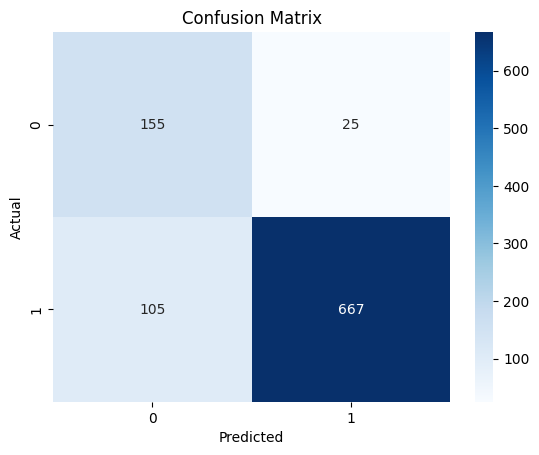

ROC Curve:


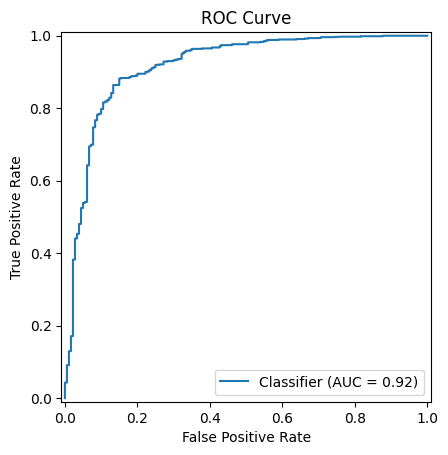

AUPRC Curve:


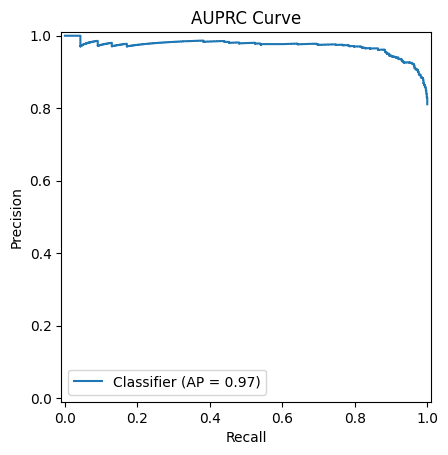

In [39]:
calc_metrics(final_model_svm)

In [40]:
save_model(final_model_svm, best_params_svm, "svm_bioactivity_model")

Model and metadata saved to saved_model/ml_models/


In [ ]:
shap_plot(final_model_svm)

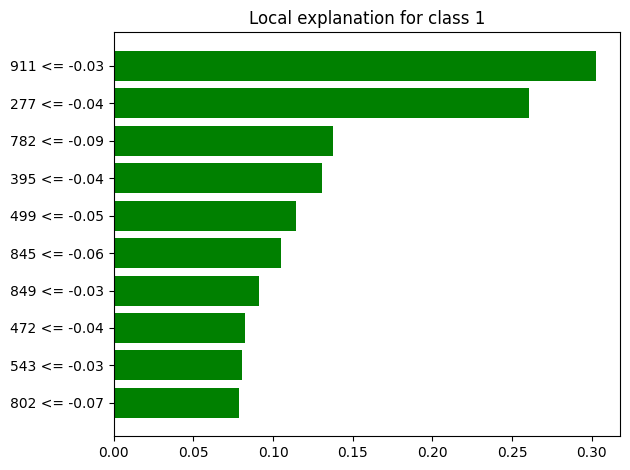


Feature contributions:
[('911 <= -0.03', 0.3026447902186193), ('277 <= -0.04', 0.26048903949675317), ('782 <= -0.09', 0.13735240368978446), ('395 <= -0.04', 0.1304591724730728), ('499 <= -0.05', 0.11412449744423452), ('845 <= -0.06', 0.10488271948580676), ('849 <= -0.03', 0.09087758974343749), ('472 <= -0.04', 0.08209143437356617), ('543 <= -0.03', 0.08069554994149634), ('802 <= -0.07', 0.07887232874890782)]

Explanation as dict:
{1: [(911, 0.3026447902186193), (277, 0.26048903949675317), (782, 0.13735240368978446), (395, 0.1304591724730728), (499, 0.11412449744423452), (845, 0.10488271948580676), (849, 0.09087758974343749), (472, 0.08209143437356617), (543, 0.08069554994149634), (802, 0.07887232874890782)]}


In [ ]:
lime_plot(final_model_svm)

#### KNN 

In [44]:
import optuna
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# ============================================================================
# KNN (K-Nearest Neighbors) Optimization
# ============================================================================

print("="*70)
print("KNN HYPERPARAMETER OPTIMIZATION")
print("="*70)


# Calculate class weights for imbalance
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"Class imbalance ratio: {scale_pos_weight:.2f}:1\n")

def objective_knn(trial):
    param = {
        # Number of neighbors
        "n_neighbors": trial.suggest_int("n_neighbors", 3, 20, step=5),
        
        # Distance metric
        "metric": trial.suggest_categorical("metric", ["euclidean", "manhattan", "minkowski"]),
        
        # Power parameter for Minkowski distance
        "p": trial.suggest_int("p", 1, 3) if trial.params.get("metric") == "minkowski" else 2,
        
        # Weight function
        "weights": trial.suggest_categorical("weights", ["distance"]),
        
        # Algorithm to compute nearest neighbors
        "algorithm": trial.suggest_categorical("algorithm", ["auto", "ball_tree", "kd_tree", "brute"]),
        
        # Leaf size for ball_tree or kd_tree
        "leaf_size": trial.suggest_int("leaf_size", 10, 20, step=5),

        "n_jobs": -1
    }
    
    # Remove p if not minkowski metric
    if param["metric"] != "minkowski":
        param.pop("p", None)
    
    model = KNeighborsClassifier(**param)
    model.fit(X_train, y_train)
    
    # Predict probabilities for AUC (using predict_proba)
    preds_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, preds_proba)
    
    return auc  # Optuna minimizes, so invert AUC

# Create and run study
study_knn = optuna.create_study(
    direction="maximize",
    study_name="knn_optimization",
    sampler=optuna.samplers.TPESampler(seed=42)
)

print("Starting KNN optimization...")
study_knn.optimize(objective_knn, n_trials=31, show_progress_bar=True)

print("\n" + "="*70)
print("KNN OPTIMIZATION RESULTS")
print("="*70)
print(f"Best trial: {study_knn.best_trial.number}")
print(f"Best AUC: {1 - study_knn.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study_knn.best_params.items():
    print(f"  {key}: {value}")

# Train final KNN model with best params
print("\n" + "="*70)
print("TRAINING FINAL KNN MODEL")
print("="*70)

best_params_knn = study_knn.best_params.copy()


final_model_knn = KNeighborsClassifier(**best_params_knn)
final_model_knn.fit(X_train_full, y_train_full)

# Evaluate on test set
y_pred_knn = final_model_knn.predict(X_test)
y_pred_proba_knn = final_model_knn.predict_proba(X_test)[:, 1]

print(f"\nFinal KNN Model Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_pred_proba_knn):.4f}")

print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

[I 2025-11-21 10:17:59,678] A new study created in memory with name: knn_optimization


KNN HYPERPARAMETER OPTIMIZATION
Class imbalance ratio: 0.24:1

Starting KNN optimization...


  0%|          | 0/31 [00:00<?, ?it/s]e:\ML\BioActivity\.venv\Lib\site-packages\optuna\distributions.py:702: UserWarning: The distribution is specified by [3, 20] and step=5, but the range is not divisible by `step`. It will be replaced by [3, 18].
  warnings.warn(
Best trial: 0. Best value: 0.900321:   3%|▎         | 1/31 [00:00<00:04,  6.63it/s]

[I 2025-11-21 10:17:59,828] Trial 0 finished with value: 0.9003205756362516 and parameters: {'n_neighbors': 8, 'metric': 'euclidean', 'weights': 'distance', 'algorithm': 'brute', 'leaf_size': 15}. Best is trial 0 with value: 0.9003205756362516.


e:\ML\BioActivity\.venv\Lib\site-packages\optuna\distributions.py:702: UserWarning: The distribution is specified by [3, 20] and step=5, but the range is not divisible by `step`. It will be replaced by [3, 18].
  warnings.warn(
Best trial: 1. Best value: 0.915688:   6%|▋         | 2/31 [00:00<00:06,  4.26it/s]e:\ML\BioActivity\.venv\Lib\site-packages\optuna\distributions.py:702: UserWarning: The distribution is specified by [3, 20] and step=5, but the range is not divisible by `step`. It will be replaced by [3, 18].
  warnings.warn(


...

[I 2025-11-21 10:18:16,632] Trial 27 finished with value: 0.9156879077190133 and parameters: {'n_neighbors': 13, 'metric': 'manhattan', 'weights': 'distance', 'algorithm': 'auto', 'leaf_size': 10}. Best is trial 1 with value: 0.9156879077190133.


Best trial: 1. Best value: 0.915688:  94%|█████████▎| 29/31 [00:17<00:01,  1.65it/s]e:\ML\BioActivity\.venv\Lib\site-packages\optuna\distributions.py:702: UserWarning: The distribution is specified by [3, 20] and step=5, but the range is not divisible by `step`. It will be replaced by [3, 18].
  warnings.warn(
Best trial: 1. Best value: 0.915688:  97%|█████████▋| 30/31 [00:17<00:00,  2.15it/s]e:\ML\BioActivity\.venv\Lib\site-packages\optuna\distributions.py:702: UserWarning: The distribution is specified by [3, 20] and step=5, but the range is not divisible by `step`. It will be replaced by [3, 18].
  warnings.warn(


[I 2025-11-21 10:18:17,436] Trial 28 finished with value: 0.9009575272279307 and parameters: {'n_neighbors': 8, 'metric': 'euclidean', 'weights': 'distance', 'algorithm': 'kd_tree', 'leaf_size': 15}. Best is trial 1 with value: 0.9156879077190133.
[I 2025-11-21 10:18:17,570] Trial 29 finished with value: 0.8872665677408518 and parameters: {'n_neighbors': 3, 'metric': 'minkowski', 'p': 2, 'weights': 'distance', 'algorithm': 'brute', 'leaf_size': 15}. Best is trial 1 with value: 0.9156879077190133.


Best trial: 1. Best value: 0.915688: 100%|██████████| 31/31 [00:18<00:00,  1.72it/s]


[I 2025-11-21 10:18:17,705] Trial 30 finished with value: 0.8930341294061652 and parameters: {'n_neighbors': 18, 'metric': 'euclidean', 'weights': 'distance', 'algorithm': 'brute', 'leaf_size': 10}. Best is trial 1 with value: 0.9156879077190133.

KNN OPTIMIZATION RESULTS
Best trial: 1
Best AUC: 0.0843

Best hyperparameters:
  n_neighbors: 13
  metric: manhattan
  weights: distance
  algorithm: brute
  leaf_size: 15

TRAINING FINAL KNN MODEL

Final KNN Model Performance:
  Accuracy: 0.9191
  ROC-AUC: 0.9358

Confusion Matrix:
[[126  54]
 [ 23 749]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.70      0.77       180
           1       0.93      0.97      0.95       772

    accuracy                           0.92       952
   macro avg       0.89      0.84      0.86       952
weighted avg       0.92      0.92      0.92       952



Accuracy: 0.9191
Balanced Acc.: 0.8351
Cohen's Kappa: 0.7176
Precision: 0.9328
Recall: 0.9702
F1 Score: 0.9511
ROC-AUC: 0.9358
AUPRC: 0.9767
MCC: 0.7223
NPV: 0.8456
Specificity: 0.7000
Sensitivity: 0.9702
Informedness: 0.6702
DOR: 75.9855
Brier Score: 0.0634
********************
Confusion Matrix:


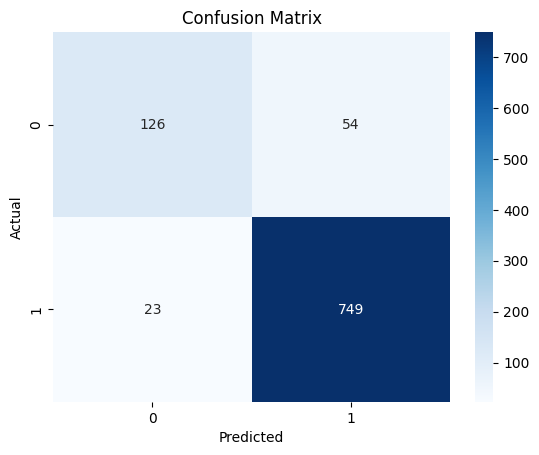

ROC Curve:


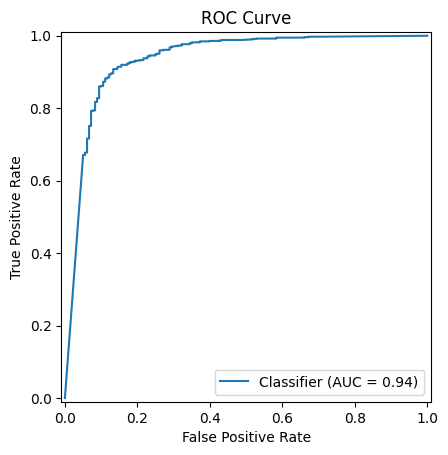

AUPRC Curve:


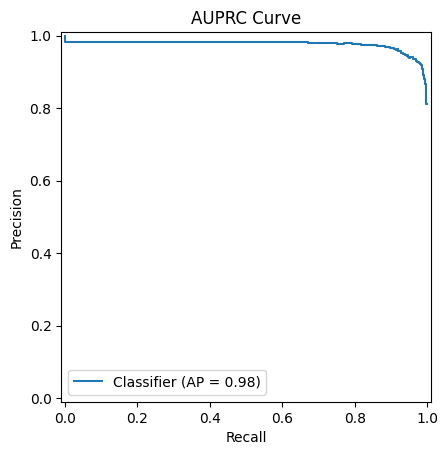

In [45]:
calc_metrics(final_model_knn)

In [ ]:
calc_loss(final_model_knn)

Log Loss(Test): 0.7723670602184197
Log Loss(Train): 0.011758831433212297
Log Loss(Train): 0.011758831433212297
Focal Loss (Test Set): 0.0959
Focal Loss (Test Set): 0.0959


In [ ]:
lime_plot(final_model_knn)

In [46]:
save_model(final_model_knn, best_params_knn, "knn_bioactivity_model")

Model and metadata saved to saved_model/ml_models/


#### Ensembles

##### Voting 

In [52]:
import joblib

# Replace with your actual model name
model_name = "xgboost_bioactivity_model"  # or "random_forest_bioactivity_model", etc.
model_path = f"saved_model/ml_models/{model_name}.pkl"

# Load the model
final_model_xgb = joblib.load(model_path)


# Replace with your actual model name
model_name = "random_forest_bioactivity_model"  # or "random_forest_bioactivity_model", etc.
model_path = f"saved_model/ml_models/{model_name}.pkl"

# Load the model
final_model_rf = joblib.load(model_path)



# Replace with your actual model name
model_name = "lightgbm_bioactivity_model"  # or "random_forest_bioactivity_model", etc.
model_path = f"saved_model/ml_models/{model_name}.pkl"

# Load the model
final_model_lgbm = joblib.load(model_path)



# Replace with your actual model name
model_name = "catboost_bioactivity_model"  # or "random_forest_bioactivity_model", etc.
model_path = f"saved_model/ml_models/{model_name}.pkl"

# Load the model
final_model_cat = joblib.load(model_path)



# Replace with your actual model name
model_name = "svm_bioactivity_model"  # or "random_forest_bioactivity_model", etc.
model_path = f"saved_model/ml_models/{model_name}.pkl"

# Load the model
final_model_svm = joblib.load(model_path)


# Replace with your actual model name
model_name = "extratree_bioactivity_model"  # or "random_forest_bioactivity_model", etc.
model_path = f"saved_model/ml_models/{model_name}.pkl"

# Load the model
final_model_et = joblib.load(model_path)

In [53]:
import optuna
from sklearn.ensemble import (
    VotingClassifier, 
    StackingClassifier, 
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, f1_score
from sklearn.preprocessing import StandardScaler
import numpy as np



# ============================================================================
# 1. VOTING CLASSIFIER (Soft Voting)
# ============================================================================

print("="*70)
print("VOTING CLASSIFIER OPTIMIZATION")
print("="*70)

def objective_voting(trial):
    """
    Voting Classifier with multiple base estimators

    NOTE: to avoid multiprocessing / pickling issues (BrokenProcessPool),
    force single-threaded / no-process parallelism for estimators and the
    VotingClassifier (n_jobs=1). Also enable probability=True for SVC so
    soft voting can use predict_proba.
    """
    
    # Define base estimators with their hyperparameters
    
    # XGBoost
    # xgb_params = {
    #     'n_estimators': trial.suggest_int('xgb_n_estimators', 50, 300),
    #     'max_depth': trial.suggest_int('xgb_max_depth', 3, 10),
    #     'learning_rate': trial.suggest_float('xgb_learning_rate', 0.01, 0.3, log=True),
    #     'scale_pos_weight': scale_pos_weight,
    #     'random_state': 42,
    #     'eval_metric': 'auc',
    #     'n_jobs': 1
    # }
    
    # # LightGBM
    # lgbm_params = {
    #     'n_estimators': trial.suggest_int('lgbm_n_estimators', 50, 300),
    #     'max_depth': trial.suggest_int('lgbm_max_depth', 3, 10),
    #     'learning_rate': trial.suggest_float('lgbm_learning_rate', 0.01, 0.3, log=True),
    #     'scale_pos_weight': scale_pos_weight,
    #     'random_state': 42,
    #     'verbosity': -1,
    #     'n_jobs': 1
    # }
    
    # # Random Forest (via sklearn)
    # from sklearn.ensemble import RandomForestClassifier
    # rf_params = {
    #     'n_estimators': trial.suggest_int('rf_n_estimators', 50, 300),
    #     'max_depth': trial.suggest_int('rf_max_depth', 3, 20),
    #     'class_weight': 'balanced',
    #     'random_state': 42,
    #     'n_jobs': 1
    # }

    # # Support Vector (enable probability for soft voting)
    # sf_params={
    #     'kernel': trial.suggest_categorical('svm_kernel', ['linear', 'rbf', 'poly', 'sigmoid']),
    #     'C': trial.suggest_float('svm_C', 0.01, 10, log=True),
    #     'gamma': trial.suggest_categorical('svm_gamma', ['scale', 'auto']),
    #     'class_weight': 'balanced',
    #     'probability': True,
    #     'random_state': 42
    # }

    
    # # Logistic Regression
    # lr_params = {
    #     'C': trial.suggest_float('lr_C', 0.01, 10, log=True),
    #     'class_weight': 'balanced',
    #     'random_state': 42,
    #     'max_iter': 1000,
    #     'n_jobs': 1
    # }
    
    # Create base estimators
    estimators = [
        ('xgb', final_model_xgb),
        ('lgbm', final_model_lgbm),
        ('rf', final_model_rf),
        ('cat', final_model_cat),
        ('sf', final_model_svm),
        ('ext', final_model_et)
    ]
    
    # Voting type
    voting = trial.suggest_categorical('voting', ['soft', 'hard'])
    
    # Weights for each estimator (if soft voting)
    if voting == 'soft':
        weights = [
            trial.suggest_float(f'weight_{name}', 0.5, 2.0)
            for name in ['xgb', 'lgbm', 'rf', 'cat', 'sf', 'ext']
        ]
    else:
        weights = None
    
    # Create voting classifier
    # Set n_jobs=1 to avoid nested multiprocessing / pickling issues
    voting_model = VotingClassifier(
        estimators=estimators,
        voting=voting,
        weights=weights,
        n_jobs=1
    )
    
    voting_model.fit(X_train, y_train)
    
    if voting == 'soft':
        preds_proba = voting_model.predict_proba(X_val)[:, 1]
    else:
        # For hard voting, use predicted labels and return 1 - accuracy (same as before)
        preds = voting_model.predict(X_val)
        auc = roc_auc_score(y_val, preds)
        return auc
    
    auc = roc_auc_score(y_val, preds_proba)
    return auc

study_voting = optuna.create_study(
    direction="maximize",
    study_name="voting_optimization",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner()
)

print("Starting Voting Classifier optimization...")
study_voting.optimize(objective_voting, n_trials=31, show_progress_bar=True)

print("\n" + "="*70)
print("VOTING CLASSIFIER RESULTS")
print("="*70)
print(f"Best AUC: {study_voting.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study_voting.best_params.items():
    print(f"  {key}: {value}")


[I 2025-11-21 10:30:09,754] A new study created in memory with name: voting_optimization


VOTING CLASSIFIER OPTIMIZATION
Starting Voting Classifier optimization...


  0%|          | 0/31 [00:00<?, ?it/s]e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [10:30:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=900).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Best trial: 0. Best value: 0.857204:   3%|▎         | 1/31 [00:19<09:49, 19.63s/it]e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [10:30:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  

[I 2025-11-21 10:30:29,387] Trial 0 finished with value: 0.8572038525072097 and parameters: {'voting': 'hard'}. Best is trial 0 with value: 0.8572038525072097.


e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=900).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Best trial: 1. Best value: 0.960439:   6%|▋         | 2/31 [00:39<09:38, 19.95s/it]e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [10:30:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


...

[I 2025-11-21 10:39:57,413] Trial 28 finished with value: 0.9640927289525996 and parameters: {'voting': 'soft', 'weight_xgb': 1.3504518016948448, 'weight_lgbm': 1.8922196881882951, 'weight_rf': 1.9566561651881624, 'weight_cat': 1.460795200048445, 'weight_sf': 1.6591619083276954, 'weight_ext': 0.8874175814361605}. Best is trial 27 with value: 0.9644916986309041.


e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=900).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Best trial: 27. Best value: 0.964492:  97%|█████████▋| 30/31 [10:09<00:20, 20.93s/it]e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [10:40:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2025-11-21 10:40:19,032] Trial 29 finished with value: 0.8512018086625416 and parameters: {'voting': 'hard'}. Best is trial 27 with value: 0.9644916986309041.


e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=900).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Best trial: 27. Best value: 0.964492: 100%|██████████| 31/31 [10:30<00:00, 20.32s/it]

[I 2025-11-21 10:40:39,776] Trial 30 finished with value: 0.9625738443878266 and parameters: {'voting': 'soft', 'weight_xgb': 1.587742324549121, 'weight_lgbm': 1.38802921792744, 'weight_rf': 1.8017742260283671, 'weight_cat': 1.0809080624044292, 'weight_sf': 1.7891664701022467, 'weight_ext': 1.1761826289325492}. Best is trial 27 with value: 0.9644916986309041.

VOTING CLASSIFIER RESULTS
Best AUC: 0.9645

Best hyperparameters:
  voting: soft
  weight_xgb: 1.2596072216604863
  weight_lgbm: 1.8015243158548453
  weight_rf: 1.997909627607913
  weight_cat: 1.0766023113224443
  weight_sf: 1.4934874656915478
  weight_ext: 0.8358873684991758


In [56]:
estimators = [
        ('xgb', final_model_xgb),
        ('lgbm', final_model_lgbm),
        ('rf', final_model_rf),
        ('cat', final_model_cat),
        ('sf', final_model_svm),
        ('ext', final_model_et)
    ]

best_weights = [
    1.2596072216604863,  # weight_xgb
    1.8015243158548453,  # weight_lgbm
    1.997909627607913,  # weight_rf
    1.0766023113224443,  # weight_cat
    1.4934874656915478,  # weight_sf
    0.8358873684991758   # weight_ext
]

# Create the VotingClassifier with the best parameters
voting_model = VotingClassifier(
    estimators=estimators,
    voting='soft',  # Best voting type from Optuna
    weights=best_weights,  # Best weights from Optuna
    n_jobs=1  # Avoid multiprocessing issues
)

# Fit the VotingClassifier (uses pre-trained models without retraining)
voting_model.fit(X_train_full, y_train_full)

# Predict on the validation and test sets

y_test_pred = voting_model.predict(X_test)
y_test_pred_proba = voting_model.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_pred_proba)

# Detailed classification report for validation set
test_report = classification_report(y_test, y_test_pred)
print("classification_report")
print(test_report)

e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [10:46:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=900).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


classification_report
              precision    recall  f1-score   support

           0       0.91      0.74      0.82       180
           1       0.94      0.98      0.96       772

    accuracy                           0.94       952
   macro avg       0.93      0.86      0.89       952
weighted avg       0.94      0.94      0.94       952



e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.9380
Balanced Acc.: 0.8638
Cohen's Kappa: 0.7826
Precision: 0.9429
Recall: 0.9832
F1 Score: 0.9626
ROC-AUC: 0.9641
AUPRC: 0.9886
MCC: 0.7885
NPV: 0.9116
Specificity: 0.7444
Sensitivity: 0.9832
Informedness: 0.7276
DOR: 170.0769
Brier Score: 0.0518
********************
Confusion Matrix:


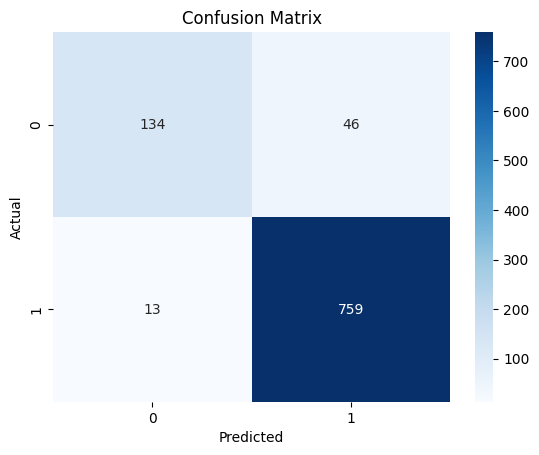

ROC Curve:


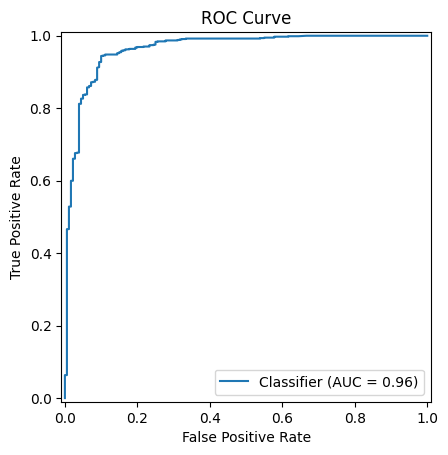

AUPRC Curve:


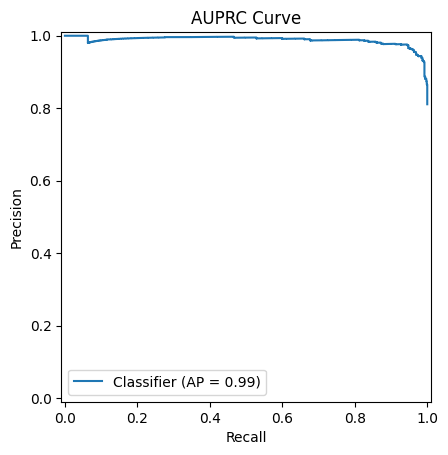

In [58]:
calc_metrics(voting_model)

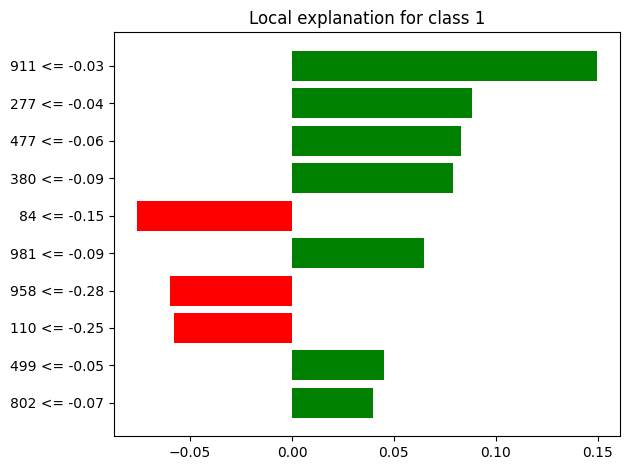


Feature contributions:
[('911 <= -0.03', 0.1496308227435044), ('277 <= -0.04', 0.08820697631825977), ('477 <= -0.06', 0.08290040697853725), ('380 <= -0.09', 0.07897755564758215), ('84 <= -0.15', -0.07602296436455713), ('981 <= -0.09', 0.06474482480789492), ('958 <= -0.28', -0.0600420255951942), ('110 <= -0.25', -0.05765289937634996), ('499 <= -0.05', 0.04509903934089284), ('802 <= -0.07', 0.03953451151167671)]

Explanation as dict:
{1: [(np.int64(911), np.float64(0.1496308227435044)), (np.int64(277), np.float64(0.08820697631825977)), (np.int64(477), np.float64(0.08290040697853725)), (np.int64(380), np.float64(0.07897755564758215)), (np.int64(84), np.float64(-0.07602296436455713)), (np.int64(981), np.float64(0.06474482480789492)), (np.int64(958), np.float64(-0.0600420255951942)), (np.int64(110), np.float64(-0.05765289937634996)), (np.int64(499), np.float64(0.04509903934089284)), (np.int64(802), np.float64(0.03953451151167671))]}


In [ ]:
lime_plot(voting_model)

In [59]:
save_model(voting_model, study_voting.best_params, "voting_bioactivity_model")

Model and metadata saved to saved_model/ml_models/


<!-- ##### Stacking -->

In [ ]:
# import joblib
# model_ = joblib.load("saved_model/ml_models/lightgbm_bioactivity_model.pkl")

In [74]:
import optuna
from optuna.samplers import TPESampler
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier, RidgeClassifierCV
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
import numpy as np
import os

# ============================================================================
# HYBRID APPROACH: Speed + Accuracy Balance
# ============================================================================

def objective_stacking_balanced(trial):
    """
    BALANCED VERSION: Good speed (5-8 min/trial) + High accuracy
    
    Speed optimizations:
    - Fixed CV=3 (vs 3-5)
    - Moderate n_jobs=2
    - Reduced but comprehensive search space
    
    Accuracy maintained:
    - All 5 meta-learner types (LR, XGB, LGBM, Cat, SVM)
    - Key hyperparameters still tuned
    - Passthrough still optimized
    """
    
    base_estimators = [
        ('xgb', final_model_xgb),
        ('lgbm', final_model_lgbm),
        ('catboost', final_model_cat),
        ('rf', final_model_rf),
        ('sf', final_model_svm),
        ('ext', final_model_et)
    ]
    
    # All meta-learners included for accuracy
    meta_learner_type = trial.suggest_categorical('meta_learner', ['lr', 'ridge', 'ridge_cv'])
    
    if meta_learner_type == 'lr':
        # Simplified but still effective
        meta_penalty = trial.suggest_categorical('meta_penalty', ['l2', 'l1', 'elasticnet'])
         
        meta_solver = trial.suggest_categorical('meta_solver', ['lbfgs', 'saga'])
        
        if meta_penalty == 'l2' and meta_solver not in ['lbfgs', 'saga']:
            raise optuna.TrialPruned()
        if meta_penalty in ['l1', 'elasticnet'] and meta_solver != 'saga':
            raise optuna.TrialPruned()
        
        params = {
            'C': trial.suggest_float('meta_C', 0.01, 10, log=True),
            'class_weight': trial.suggest_categorical('meta_class_weight', ['balanced']),
            'random_state': 42,
            'max_iter': 1000,  # Fixed for speed
            'solver': meta_solver,
            'penalty': meta_penalty,
            'tol': 1e-4 # Fixed for speed
        }
        if meta_penalty == 'elasticnet':
            params['l1_ratio'] = trial.suggest_float('meta_l1_ratio', 0.0, 1.0)
        
        meta_learner = LogisticRegression(**params)
    
    elif meta_learner_type == 'ridge':
        meta_learner = RidgeClassifier(
            alpha=trial.suggest_float('meta_alpha', 1e-3, 10.0, log=True),
            class_weight=trial.suggest_categorical('meta_class_weight', ['balanced']),
            max_iter=1000,
            tol=1e-4
        )
    else:
        meta_learner = RidgeClassifierCV(
            alphas=np.logspace(-3, 3, 10),
            class_weight=trial.suggest_categorical('meta_class_weight', ['balanced']),
            cv=3
        )   
    
    
    # Moderate n_jobs=2 (faster than 1, safer than -1)
    model = StackingClassifier(
        estimators=base_estimators,
        final_estimator=meta_learner,
        passthrough=trial.suggest_categorical('passthrough', [True, False])  # Keep for accuracy
    )
    
    try:
        model.fit(X_train, y_train)
        # Only call predict_proba if supported
        if hasattr(model, "predict_proba"):
            preds_proba = model.predict_proba(X_val)[:, 1]
            auc = roc_auc_score(y_val, preds_proba)
        else:
            preds = model.predict(X_val)
            auc = roc_auc_score(y_val, preds)
        return auc
    except Exception as e:
        print(f"Trial failed: {e}")
        return 0.0



# ============================================================================
# EXECUTION: Choose Your Strategy
# ============================================================================

os.environ['OPTUNA_DISABLE_FORK'] = '1'

print("\n" + "="*80)
print("STACKING OPTIMIZATION: SPEED + ACCURACY BALANCED")
print("="*80)

# ============================================================================
# OPTION 1: BALANCED (Recommended - Good for most cases)
# Time: ~5-8 min/trial, 30 trials = 2.5-4 hours
# Accuracy: High (all meta-learners, key params tuned)
# ============================================================================

print("\n[OPTION 1: BALANCED APPROACH]")
print("Expected accuracy: High (comprehensive search)")

study_balanced = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3)
)

study_balanced.optimize(objective_stacking_balanced, n_trials=31, show_progress_bar=True)

print(f"\n✓ Best AUC: {study_balanced.best_value:.4f}")
print(f"Best meta-learner: {study_balanced.best_params['meta_learner']}")


# ============================================================================
# RESULTS AND FINAL MODEL
# ============================================================================

study_final = study_balanced  # or study_stage2 if using two-stage

print("\n" + "="*80)
print("OPTIMIZATION RESULTS")
print("="*80)
print(f"Best Validation AUC: {1 - study_final.best_value:.4f}")
print(f"\nBest Parameters:")
for key, value in study_final.best_params.items():
    print(f"  {key}: {value}")

[I 2025-11-21 22:52:22,454] A new study created in memory with name: no-name-9a020033-3e35-4fca-9a63-611ec73c81fc



STACKING OPTIMIZATION: SPEED + ACCURACY BALANCED

[OPTION 1: BALANCED APPROACH]
Expected accuracy: High (comprehensive search)


  0%|          | 0/31 [00:00<?, ?it/s]e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:52:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=900).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:52:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:52:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, 

[I 2025-11-21 22:54:31,470] Trial 0 finished with value: 0.8610920570036678 and parameters: {'meta_learner': 'ridge', 'meta_alpha': 0.24810409748678125, 'meta_class_weight': 'balanced', 'passthrough': True}. Best is trial 0 with value: 0.8610920570036678.


e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=900).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:54:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:54:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:54:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivi

...

[I 2025-11-21 23:52:57,522] Trial 28 finished with value: 0.8815480023518214 and parameters: {'meta_learner': 'ridge_cv', 'meta_class_weight': 'balanced', 'passthrough': False}. Best is trial 25 with value: 0.9640087353361145.


e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=900).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [23:53:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [23:53:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [23:53:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivi

[I 2025-11-21 23:55:10,244] Trial 29 finished with value: 0.8715632611921493 and parameters: {'meta_learner': 'ridge', 'meta_alpha': 0.0016462494656141725, 'meta_class_weight': 'balanced', 'passthrough': False}. Best is trial 25 with value: 0.9640087353361145.


e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [23:55:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=900).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [23:55:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [23:55:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivi

[I 2025-11-21 23:57:23,980] Trial 30 finished with value: 0.8675245681328219 and parameters: {'meta_learner': 'ridge', 'meta_alpha': 9.777198713756135, 'meta_class_weight': 'balanced', 'passthrough': False}. Best is trial 25 with value: 0.9640087353361145.

✓ Best AUC: 0.9640
Best meta-learner: lr

OPTIMIZATION RESULTS
Best Validation AUC: 0.0360

Best Parameters:
  meta_learner: lr
  meta_penalty: l2
  meta_solver: lbfgs
  meta_C: 0.13106062699357715
  meta_class_weight: balanced
  passthrough: False


In [75]:
for key, value in study_final.best_params.items():
    print(f"  {key}: {value}")

  meta_learner: lr
  meta_penalty: l2
  meta_solver: lbfgs
  meta_C: 0.13106062699357715
  meta_class_weight: balanced
  passthrough: False


In [76]:
import pickle

# Save to pickle (after optimization)
with open("study_stacking.pkl", "wb") as f:
    pickle.dump(study_final, f)
print("Study saved to study_stacking.pkl")



Study saved to study_stacking.pkl


In [ ]:
# study_final

e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [02:49:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=900).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [02:50:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [02:50:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivi


Final Stacking Model Performance:
  Accuracy: 0.9265
  ROC-AUC: 0.9573

Confusion Matrix:
[[156  24]
 [ 46 726]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.87      0.82       180
           1       0.97      0.94      0.95       772

    accuracy                           0.93       952
   macro avg       0.87      0.90      0.89       952
weighted avg       0.93      0.93      0.93       952


EVALUATING FINAL STACKING MODEL


e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.9265
Balanced Acc.: 0.9035
Cohen's Kappa: 0.7710
Precision: 0.9680
Recall: 0.9404
F1 Score: 0.9540
ROC-AUC: 0.9573
AUPRC: 0.9882
MCC: 0.7730
NPV: 0.7723
Specificity: 0.8667
Sensitivity: 0.9404
Informedness: 0.8071
DOR: 102.5870
Brier Score: 0.0578
********************
Confusion Matrix:


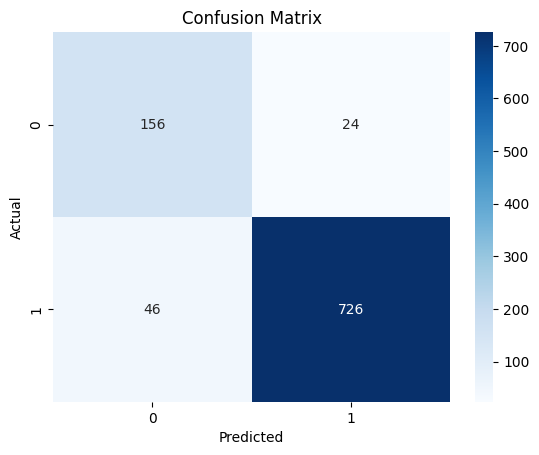

ROC Curve:


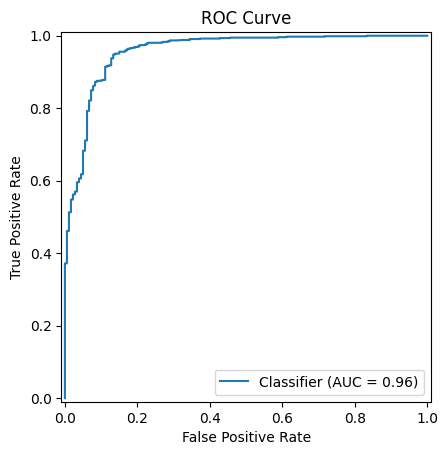

AUPRC Curve:


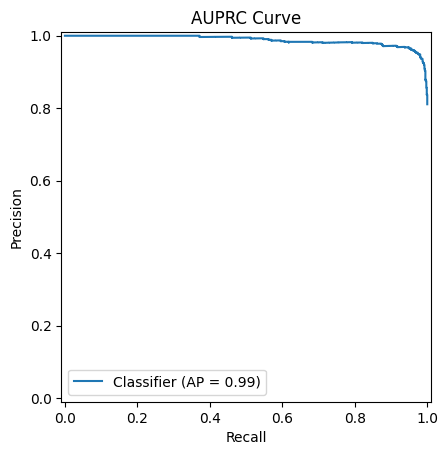

Model and metadata saved to saved_model/ml_models/
Final Stacking model saved as 'stacking_bioactivity_model.pkl'


In [83]:
best_params = study_final.best_params
scale_pos_weight_full = (y_train_full == 0).sum() / (y_train_full == 1).sum()
final_model_stacking = StackingClassifier(
    estimators=[
        ('xgb', final_model_xgb),
        ('lgbm', final_model_lgbm),
        ('catboost', final_model_cat),
        ('rf', final_model_rf),
        ('sf', final_model_svm),
        ('ext', final_model_et)
    ],

    final_estimator = LogisticRegression(
        C=best_params['meta_C'],
        class_weight='balanced',
        random_state=42,
        max_iter=2000,
        solver=best_params['meta_solver'],
        penalty=best_params['meta_penalty'],
        tol=1e-4
    ) ,
    stack_method='predict_proba',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    passthrough=True
)

final_model_stacking.fit(X_train_full, y_train_full)
y_test_pred = final_model_stacking.predict(X_test)
y_test_pred_proba = final_model_stacking.predict_proba(X_test)[:, 1]
final_auc = roc_auc_score(y_test, y_test_pred_proba)
print(f"\nFinal Stacking Model Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"  ROC-AUC: {final_auc:.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))
print(f"\nClassification Report:")
print(classification_report(y_test, y_test_pred))
print("\n" + "="*80)
print("EVALUATING FINAL STACKING MODEL")
calc_metrics(final_model_stacking)
save_model(final_model_stacking, best_params, "stacking_bioactivity_model")
print("Final Stacking model saved as 'stacking_bioactivity_model.pkl'")

In [79]:
# ============================================================================
# 3. BAGGING CLASSIFIER
# ============================================================================

print("\n\n" + "="*70)
print("BAGGING CLASSIFIER OPTIMIZATION")
print("="*70)

def objective_bagging(trial):
    """
    Bagging Classifier with optimized base estimator
    """
    
    # Base estimator choice
    base_estimator_type = trial.suggest_categorical('base_estimator', ['dt', 'svm', 'knn'])
    
    if base_estimator_type == 'dt':
        base_estimator = DecisionTreeClassifier(
            max_depth=trial.suggest_int('dt_max_depth', 3, 20),
            min_samples_split=trial.suggest_int('dt_min_samples_split', 2, 10),
            min_samples_leaf=trial.suggest_int('dt_min_samples_leaf', 1, 5),
            class_weight='balanced',
            random_state=42
        )
    elif base_estimator_type == 'svm':
        base_estimator = SVC(
            C=trial.suggest_float('svm_C', 0.1, 10, log=True),
            kernel=trial.suggest_categorical('svm_kernel', ['rbf', 'linear']),
            class_weight='balanced',
            probability=True,
            random_state=42
        )
    else:  # knn
        base_estimator = KNeighborsClassifier(
            n_neighbors=trial.suggest_int('knn_n_neighbors', 3, 20),
            weights=trial.suggest_categorical('knn_weights', ['uniform', 'distance']),
            metric='minkowski'
        )
    
    # Bagging parameters
    param = {
        'estimator': base_estimator,
        'n_estimators': trial.suggest_int('n_estimators', 10, 100),
        'max_samples': trial.suggest_float('max_samples', 0.5, 1.0),
        'max_features': trial.suggest_float('max_features', 0.5, 1.0),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'bootstrap_features': trial.suggest_categorical('bootstrap_features', [True, False]),
        'random_state': 42,
    }
    
    model = BaggingClassifier(**param)
    
    try:
        # Fit the model
        model.fit(X_train, y_train)
        
        # Get predictions
        preds_proba = model.predict_proba(X_val)[:, 1]
        
        # Calculate AUC
        auc = roc_auc_score(y_val, preds_proba)
        
        return auc
    
    except Exception as e:
        print(f"Trial failed with error: {e}")
        return 0  # Return worst score on failure

study_bagging = optuna.create_study(
    direction="maximize",
    study_name="bagging_optimization",
    sampler=optuna.samplers.TPESampler(seed=42)
)

print("Starting Bagging Classifier optimization...")
study_bagging.optimize(objective_bagging, n_trials=30, show_progress_bar=True)

print("\n" + "="*70)
print("BAGGING CLASSIFIER RESULTS")
print("="*70)
print(f"Best AUC: {1 - study_bagging.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study_bagging.best_params.items():
    print(f"  {key}: {value}")




[I 2025-11-22 00:15:46,703] A new study created in memory with name: bagging_optimization




BAGGING CLASSIFIER OPTIMIZATION
Starting Bagging Classifier optimization...


Best trial: 0. Best value: 0.948799:   3%|▎         | 1/30 [01:36<46:26, 96.10s/it]

[I 2025-11-22 00:17:22,799] Trial 0 finished with value: 0.9487988912842624 and parameters: {'base_estimator': 'svm', 'svm_C': 1.5751320499779735, 'svm_kernel': 'rbf', 'n_estimators': 15, 'max_samples': 0.9330880728874675, 'max_features': 0.8005575058716043, 'bootstrap': True, 'bootstrap_features': True}. Best is trial 0 with value: 0.9487988912842624.


Best trial: 0. Best value: 0.948799:   7%|▋         | 2/30 [01:38<19:07, 40.97s/it]

...

[I 2025-11-22 00:25:41,297] Trial 27 finished with value: 0.9517666657334043 and parameters: {'base_estimator': 'dt', 'dt_max_depth': 20, 'dt_min_samples_split': 3, 'dt_min_samples_leaf': 4, 'n_estimators': 72, 'max_samples': 0.9244915385900426, 'max_features': 0.801611390106866, 'bootstrap': True, 'bootstrap_features': True}. Best is trial 22 with value: 0.9575412268667581.


Best trial: 22. Best value: 0.957541:  97%|█████████▋| 29/30 [25:47<04:54, 294.93s/it]

[I 2025-11-22 00:41:33,838] Trial 28 finished with value: 0.9242167595262759 and parameters: {'base_estimator': 'svm', 'svm_C': 0.18189366309739655, 'svm_kernel': 'rbf', 'n_estimators': 85, 'max_samples': 0.9732709746222247, 'max_features': 0.8837994836600225, 'bootstrap': True, 'bootstrap_features': True}. Best is trial 22 with value: 0.9575412268667581.


Best trial: 22. Best value: 0.957541: 100%|██████████| 30/30 [26:01<00:00, 52.07s/it] 

[I 2025-11-22 00:41:48,660] Trial 29 finished with value: 0.9159853851107316 and parameters: {'base_estimator': 'knn', 'knn_n_neighbors': 19, 'knn_weights': 'distance', 'n_estimators': 97, 'max_samples': 0.9065041611766789, 'max_features': 0.811933154502673, 'bootstrap': True, 'bootstrap_features': True}. Best is trial 22 with value: 0.9575412268667581.

BAGGING CLASSIFIER RESULTS
Best AUC: 0.0425

Best hyperparameters:
  base_estimator: dt
  dt_max_depth: 18
  dt_min_samples_split: 5
  dt_min_samples_leaf: 2
  n_estimators: 88
  max_samples: 0.8335260630715573
  max_features: 0.9272566041814421
  bootstrap: True
  bootstrap_features: True


In [80]:
best_params_bagging = study_bagging.best_params
final_model_bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=best_params_bagging['dt_max_depth'],
        min_samples_split=best_params_bagging['dt_min_samples_split'],
        min_samples_leaf=best_params_bagging['dt_min_samples_leaf'],
        class_weight='balanced',
        random_state=42
    ),
    n_estimators=best_params_bagging['n_estimators'],
    max_samples=best_params_bagging['max_samples'],
    max_features=best_params_bagging['max_features'],
    bootstrap=best_params_bagging['bootstrap'],
    bootstrap_features=best_params_bagging['bootstrap_features'],
    random_state=42,
)

final_model_bagging.fit(X_train_full, y_train_full)
y_test_pred_bagging = final_model_bagging.predict(X_test)
y_test_pred_proba_bagging = final_model_bagging.predict_proba(X_test)[:, 1]
final_auc_bagging = roc_auc_score(y_test, y_test_pred_proba_bagging)
print(f"\nFinal Bagging Model Performance:")
print(f"AUC: {final_auc_bagging:.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_bagging))
print(f"\nClassification Report:")
print(classification_report(y_test, y_test_pred_bagging))



Final Bagging Model Performance:
AUC: 0.9607

Confusion Matrix:
[[143  37]
 [ 30 742]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       180
           1       0.95      0.96      0.96       772

    accuracy                           0.93       952
   macro avg       0.89      0.88      0.88       952
weighted avg       0.93      0.93      0.93       952



Accuracy: 0.9296
Balanced Acc.: 0.8778
Cohen's Kappa: 0.7670
Precision: 0.9525
Recall: 0.9611
F1 Score: 0.9568
ROC-AUC: 0.9607
AUPRC: 0.9882
MCC: 0.7672
NPV: 0.8266
Specificity: 0.7944
Sensitivity: 0.9611
Informedness: 0.7556
DOR: 95.5910
Brier Score: 0.0558
********************
Confusion Matrix:


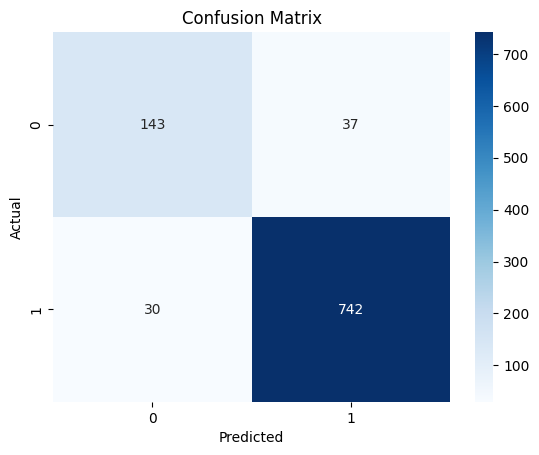

ROC Curve:


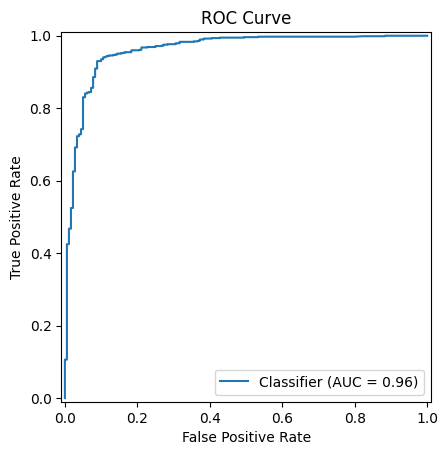

AUPRC Curve:


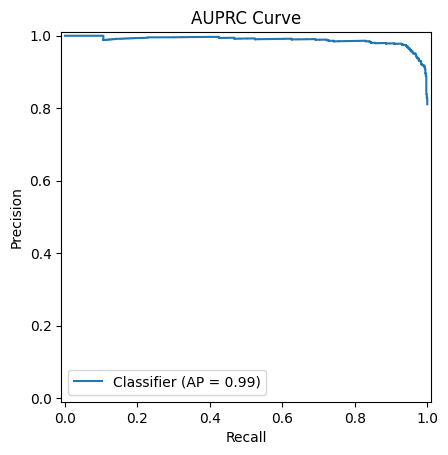

In [81]:
calc_metrics(final_model_bagging)